In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

plt.style.use("default")

In [71]:
returns = pd.read_csv(
    "../data/processed/daily_returns.csv",
    index_col="Date",
    parse_dates=True
)

print(returns.head())

print("\nDATASET SHAPE:")
print(returns.shape)

print("\nDATE RANGE:")
print("Start:", returns.index.min())
print("End:", returns.index.max())

print("\nMISSING VALUES:")
print(returns.isnull().sum())

print("\nBANKS:")
print(returns.columns.tolist())

                 CBA       NAB       WBC       ANZ       MQG
Date                                                        
2001-07-31 -0.012056  0.013137 -0.015087 -0.018263  0.015521
2001-08-01  0.029491  0.028095  0.019694  0.032714 -0.020831
2001-08-02  0.004676  0.012012  0.012160  0.006211  0.026912
2001-08-03 -0.021040  0.002968  0.007633  0.024692  0.002759
2001-08-06  0.018413  0.002071  0.002244 -0.003012  0.010179

DATASET SHAPE:
(6348, 5)

DATE RANGE:
Start: 2001-07-31 00:00:00
End: 2026-07-28 00:00:00

MISSING VALUES:
CBA    0
NAB    0
WBC    0
ANZ    0
MQG    0
dtype: int64

BANKS:
['CBA', 'NAB', 'WBC', 'ANZ', 'MQG']


In [72]:
banks = returns.columns.tolist()
n_assets = len(banks)
trading_days = 252

print("Banks:", banks)
print("Number of assets:", n_assets)
print("Trading days per year:", trading_days)

Banks: ['CBA', 'NAB', 'WBC', 'ANZ', 'MQG']
Number of assets: 5
Trading days per year: 252


In [73]:
annual_returns = returns.mean() * trading_days
annual_volatility = returns.std() * np.sqrt(trading_days)

risk_return_summary = pd.DataFrame({
    "Annual_Return": annual_returns,
    "Annual_Volatility": annual_volatility
})

print("ANNUALISED RISK AND RETURN:")
print(risk_return_summary)

ANNUALISED RISK AND RETURN:
     Annual_Return  Annual_Volatility
CBA       0.145326           0.219499
NAB       0.096125           0.239483
WBC       0.120684           0.233679
ANZ       0.119024           0.243219
MQG       0.175553           0.324745


In [74]:
risk_return_summary_percent = risk_return_summary * 100
print(
    risk_return_summary_percent.round(2)
)

     Annual_Return  Annual_Volatility
CBA          14.53              21.95
NAB           9.61              23.95
WBC          12.07              23.37
ANZ          11.90              24.32
MQG          17.56              32.47


In [75]:
daily_covariance = returns.cov()
annual_covariance = daily_covariance * trading_days

print("DAILY COVARIANCE MATRIX:")
print(daily_covariance.round(6))

print("\nANNUALISED COVARIANCE MATRIX:")
print(annual_covariance.round(4))

DAILY COVARIANCE MATRIX:
          CBA       NAB       WBC       ANZ       MQG
CBA  0.000191  0.000154  0.000154  0.000153  0.000147
NAB  0.000154  0.000228  0.000168  0.000176  0.000180
WBC  0.000154  0.000168  0.000217  0.000178  0.000159
ANZ  0.000153  0.000176  0.000178  0.000235  0.000174
MQG  0.000147  0.000180  0.000159  0.000174  0.000418

ANNUALISED COVARIANCE MATRIX:
        CBA     NAB     WBC     ANZ     MQG
CBA  0.0482  0.0388  0.0389  0.0385  0.0371
NAB  0.0388  0.0574  0.0423  0.0443  0.0453
WBC  0.0389  0.0423  0.0546  0.0449  0.0400
ANZ  0.0385  0.0443  0.0449  0.0592  0.0438
MQG  0.0371  0.0453  0.0400  0.0438  0.1055


In [76]:
correlation_matrix = returns.corr()

print("CORRELATION MATRIX:")
print(correlation_matrix.round(4))

CORRELATION MATRIX:
        CBA     NAB     WBC     ANZ     MQG
CBA  1.0000  0.7374  0.7581  0.7213  0.5207
NAB  0.7374  1.0000  0.7555  0.7603  0.5826
WBC  0.7581  0.7555  1.0000  0.7908  0.5274
ANZ  0.7213  0.7603  0.7908  1.0000  0.5544
MQG  0.5207  0.5826  0.5274  0.5544  1.0000


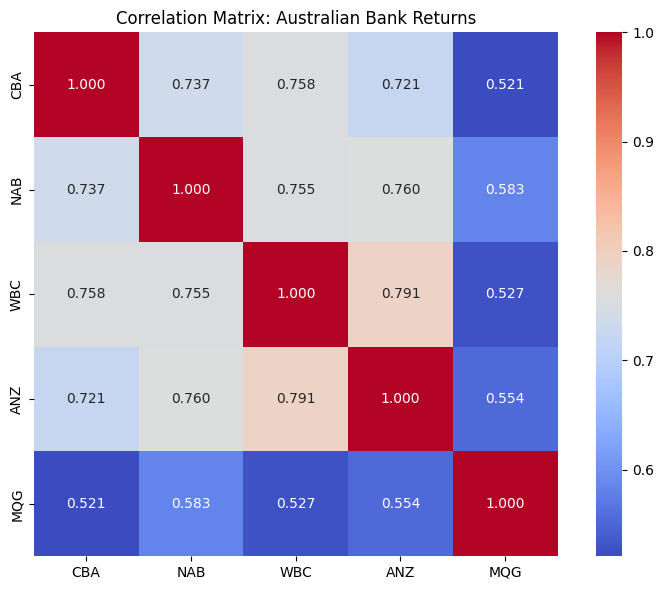

In [77]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix: Australian Bank Returns")
plt.tight_layout()
plt.show()

In [78]:
correlation_pairs = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
).stack()

highest_correlation = correlation_pairs.idxmax()
highest_value = correlation_pairs.max()

lowest_correlation = correlation_pairs.idxmin()
lowest_value = correlation_pairs.min()

print("HIGHEST CORRELATION:")
print(highest_correlation, "=", round(highest_value, 4))

print("\nLOWEST CORRELATION:")
print(lowest_correlation, "=", round(lowest_value, 4))

HIGHEST CORRELATION:
('WBC', 'ANZ') = 0.7908

LOWEST CORRELATION:
('CBA', 'MQG') = 0.5207


In [79]:
equal_weights = np.array(
    [1 / n_assets] * n_assets
)

print("EQUAL-WEIGHT PORTFOLIO WEIGHTS:")

for bank, weight in zip(banks, equal_weights):
    print(
        bank + ": " + format(weight, ".2%")
    )

EQUAL-WEIGHT PORTFOLIO WEIGHTS:
CBA: 20.00%
NAB: 20.00%
WBC: 20.00%
ANZ: 20.00%
MQG: 20.00%


In [80]:
equal_weight_portfolio_returns = returns.dot(
    equal_weights
)

equal_weight_portfolio_returns.name = (
    "Equal_Weight_Portfolio"
)

print(
    equal_weight_portfolio_returns.head()
)

Date
2001-07-31   -0.003349
2001-08-01    0.017832
2001-08-02    0.012394
2001-08-03    0.003402
2001-08-06    0.005979
Name: Equal_Weight_Portfolio, dtype: float64


In [81]:
equal_weight_annual_return = (
    equal_weight_portfolio_returns.mean()
    * trading_days
)

equal_weight_annual_volatility = (
    equal_weight_portfolio_returns.std()
    * np.sqrt(trading_days)
)

print(
    "Annualised Return: " +
    format(equal_weight_annual_return, ".2%")
)
print(
    "Annualised Volatility: " +
    format(equal_weight_annual_volatility, ".2%")
)

Annualised Return: 13.13%
Annualised Volatility: 21.47%


In [82]:
portfolio_variance_daily = np.dot(
    equal_weights.T,
    np.dot(
        daily_covariance,
        equal_weights
    )
)

portfolio_volatility_daily = np.sqrt(
    portfolio_variance_daily
)

portfolio_variance_annual = (
    portfolio_variance_daily
    * trading_days
)

portfolio_volatility_annual = np.sqrt(
    portfolio_variance_annual
)

print(
    "Portfolio Volatility (Formula): " +
    format(portfolio_volatility_annual, ".2%")
)

print(
    "Portfolio Volatility (Direct Returns): " +
    format(equal_weight_annual_volatility, ".2%")
)

Portfolio Volatility (Formula): 21.47%
Portfolio Volatility (Direct Returns): 21.47%


In [83]:
weighted_average_volatility = np.dot(
    equal_weights,
    annual_volatility
)

diversification_benefit = (
    weighted_average_volatility
    - equal_weight_annual_volatility
)

print(
    "Weighted Average Individual Volatility: " +
    format(weighted_average_volatility, ".2%")
)

print(
    "Portfolio Volatility: " +
    format(equal_weight_annual_volatility, ".2%")
)

print(
    "Diversification Benefit: " +
    format(diversification_benefit, ".2%")
)

Weighted Average Individual Volatility: 25.21%
Portfolio Volatility: 21.47%
Diversification Benefit: 3.74%


In [84]:
portfolio_comparison = risk_return_summary.copy()

portfolio_comparison.loc[
    "Equal Weight Portfolio"
] = [
    equal_weight_annual_return,
    equal_weight_annual_volatility
]

portfolio_comparison_percent = (
    portfolio_comparison * 100
)

print(
    portfolio_comparison_percent.round(2)
)

                        Annual_Return  Annual_Volatility
CBA                             14.53              21.95
NAB                              9.61              23.95
WBC                             12.07              23.37
ANZ                             11.90              24.32
MQG                             17.56              32.47
Equal Weight Portfolio          13.13              21.47


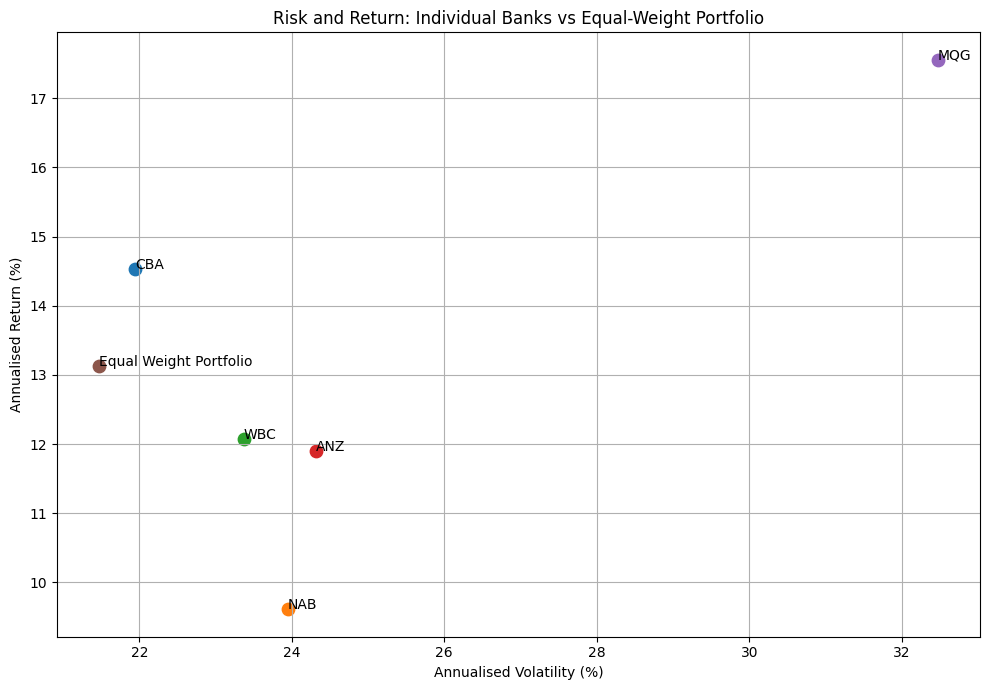

In [85]:
plt.figure(figsize=(10, 7))

for asset in portfolio_comparison.index:

    plt.scatter(
        portfolio_comparison.loc[
            asset,
            "Annual_Volatility"
        ] * 100,

        portfolio_comparison.loc[
            asset,
            "Annual_Return"
        ] * 100,

        s=80
    )

    plt.annotate(
        asset,
        (
            portfolio_comparison.loc[
                asset,
                "Annual_Volatility"
            ] * 100,

            portfolio_comparison.loc[
                asset,
                "Annual_Return"
            ] * 100
        )
    )

plt.xlabel(
    "Annualised Volatility (%)"
)
plt.ylabel(
    "Annualised Return (%)"
)
plt.title(
    "Risk and Return: Individual Banks vs Equal-Weight Portfolio"
)

plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../figures/risk_return_bank_vs_equal_weight.png",
    dpi=300
)
plt.show()

In [86]:
annual_risk_free_rate = (
    0.033821144494858124
)

daily_risk_free_rate = (
    (1 + annual_risk_free_rate)
    ** (1 / trading_days)
    - 1
)

print(
    "Annual Risk-Free Rate: " +
    format(annual_risk_free_rate, ".2%")
)

print(
    "Daily Risk-Free Rate: " +
    format(daily_risk_free_rate, ".6%")
)

Annual Risk-Free Rate: 3.38%
Daily Risk-Free Rate: 0.013200%


In [87]:
portfolio_results = portfolio_comparison.copy()
portfolio_results["Sharpe_Ratio"] = (
    (
        portfolio_results["Annual_Return"]
        - annual_risk_free_rate
    )
    /
    portfolio_results["Annual_Volatility"]
)
print(
    portfolio_results.round(4)
)

                        Annual_Return  Annual_Volatility  Sharpe_Ratio
CBA                            0.1453             0.2195        0.5080
NAB                            0.0961             0.2395        0.2602
WBC                            0.1207             0.2337        0.3717
ANZ                            0.1190             0.2432        0.3503
MQG                            0.1756             0.3247        0.4364
Equal Weight Portfolio         0.1313             0.2147        0.4542


In [88]:
custom_weights = np.array([
    0.30,
    0.15,
    0.20,
    0.15,
    0.20
])

print(
    "Total Weight:",
    custom_weights.sum()
)

for bank, weight in zip(
    banks,
    custom_weights
):
    print(
        bank + ": " + format(weight, ".2%")
    )

Total Weight: 1.0
CBA: 30.00%
NAB: 15.00%
WBC: 20.00%
ANZ: 15.00%
MQG: 20.00%


In [89]:
def calculate_portfolio_performance(weights):
    portfolio_return = np.dot(
        weights,
        annual_returns
    )

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_covariance,
                weights
            )
        )
    )

    sharpe_ratio = (
        portfolio_return
        - annual_risk_free_rate
    ) / portfolio_volatility

    return (
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio
    )

In [90]:
custom_return, custom_volatility, custom_sharpe = (
    calculate_portfolio_performance(
        custom_weights
    )
)

print(
    "Expected Annual Return: " +
    format(custom_return, ".2%")
)

print(
    "Annual Volatility: " +
    format(custom_volatility, ".2%")
)

print(
    "Sharpe Ratio: " +
    format(custom_sharpe, ".4f")
)

Expected Annual Return: 13.51%
Annual Volatility: 21.26%
Sharpe Ratio: 0.4764


In [91]:
comparison = pd.DataFrame(
    {
        "Annual_Return": [
            equal_weight_annual_return,
            custom_return
        ],

        "Annual_Volatility": [
            equal_weight_annual_volatility,
            custom_volatility
        ],

        "Sharpe_Ratio": [
            (
                equal_weight_annual_return
                - annual_risk_free_rate
            )
            /
            equal_weight_annual_volatility,

            custom_sharpe
        ]
    },

    index=[
        "Equal Weight",
        "Custom Portfolio"
    ]
)

print(
    comparison.round(4)
)

                  Annual_Return  Annual_Volatility  Sharpe_Ratio
Equal Weight             0.1313             0.2147        0.4542
Custom Portfolio         0.1351             0.2126        0.4764


In [92]:
max_weight = 0.40
print(
    "Maximum Individual Bank Allocation: " +
    format(max_weight, ".0%")
)

Maximum Individual Bank Allocation: 40%


In [93]:
np.random.seed(42)
n_portfolios = 10000
random_portfolios = []
while len(random_portfolios) < n_portfolios:

    weights = np.random.dirichlet(
        np.ones(n_assets)
    )

    if weights.max() <= max_weight:

        portfolio_return, portfolio_volatility, sharpe_ratio = (
            calculate_portfolio_performance(
                weights
            )
        )
        portfolio_data = {
            "Annual_Return":
                portfolio_return,

            "Annual_Volatility":
                portfolio_volatility,

            "Sharpe_Ratio":
                sharpe_ratio
        }

        for bank, weight in zip(
            banks,
            weights
        ):
            portfolio_data[bank] = weight

        random_portfolios.append(
            portfolio_data
        )

In [94]:
random_portfolios = pd.DataFrame(
    random_portfolios
)
print(
    random_portfolios.head()
)
print(
    "\nNUMBER OF PORTFOLIOS:"
)
print(
    len(random_portfolios)
)

   Annual_Return  Annual_Volatility  Sharpe_Ratio       CBA       NAB  \
0       0.127007           0.216240      0.430940  0.091305  0.163472   
1       0.141537           0.214395      0.502416  0.377441  0.059918   
2       0.129304           0.209509      0.455746  0.340570  0.117117   
3       0.129418           0.209540      0.456224  0.318880  0.136236   
4       0.141348           0.219535      0.489791  0.319988  0.047915   

        WBC       ANZ       MQG  
0  0.335246  0.254855  0.155122  
1  0.137802  0.181977  0.242862  
2  0.230163  0.248069  0.064081  
3  0.256095  0.205613  0.083176  
4  0.001198  0.365497  0.265401  

NUMBER OF PORTFOLIOS:
10000


In [95]:
weight_columns = banks
weight_sums = random_portfolios[
    weight_columns
].sum(axis=1)

print(
    "MINIMUM TOTAL PORTFOLIO WEIGHT:",
    weight_sums.min()
)

print(
    "MAXIMUM TOTAL PORTFOLIO WEIGHT:",
    weight_sums.max()
)

print(
    "LARGEST SINGLE BANK ALLOCATION:",
    random_portfolios[
        weight_columns
    ].max().max()
)

print(
    "NEGATIVE WEIGHTS:",
    (
        random_portfolios[
            weight_columns
        ] < 0
    ).sum().sum()
)

MINIMUM TOTAL PORTFOLIO WEIGHT: 0.9999999999999997
MAXIMUM TOTAL PORTFOLIO WEIGHT: 1.0000000000000004
LARGEST SINGLE BANK ALLOCATION: 0.39996412960104794
NEGATIVE WEIGHTS: 0


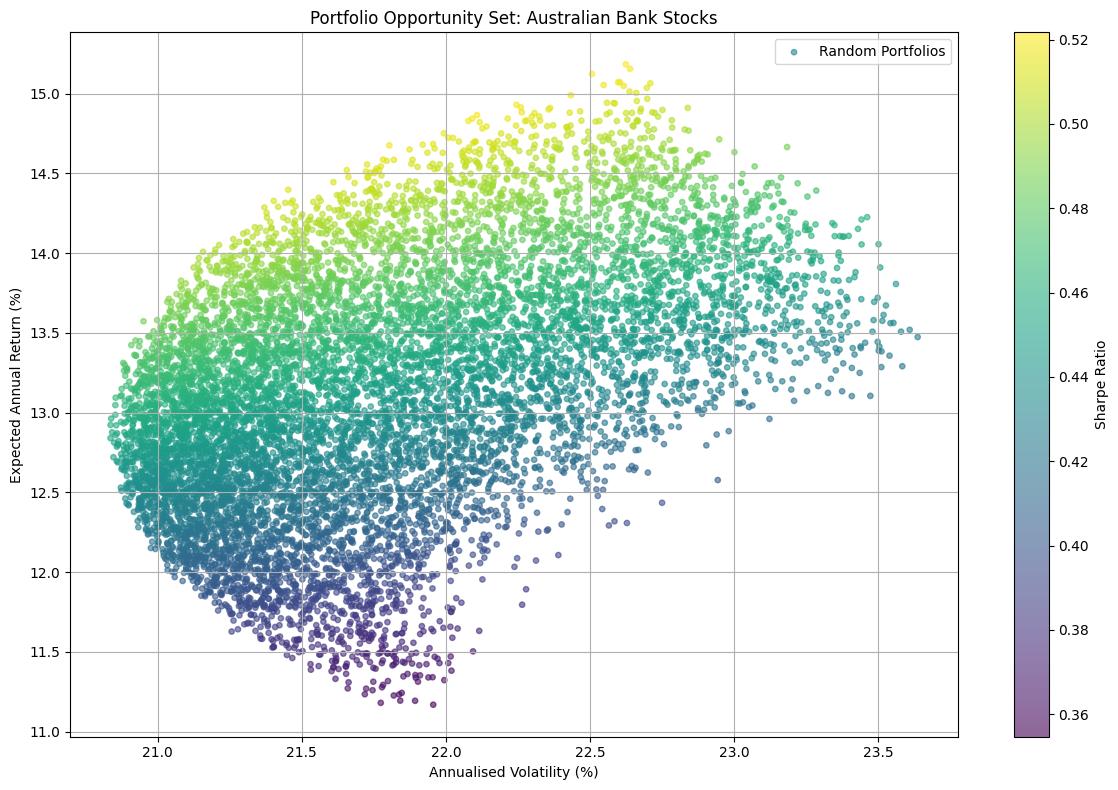

In [96]:
plt.figure(figsize=(12, 8))
plt.scatter(
    random_portfolios[
        "Annual_Volatility"
    ] * 100,

    random_portfolios[
        "Annual_Return"
    ] * 100,

    c=random_portfolios[
        "Sharpe_Ratio"
    ],

    cmap="viridis",
    alpha=0.6,
    s=15,
    label="Random Portfolios"
)

plt.colorbar(
    label="Sharpe Ratio"
)
plt.xlabel(
    "Annualised Volatility (%)"
)
plt.ylabel(
    "Expected Annual Return (%)"
)
plt.title(
    "Portfolio Opportunity Set: Australian Bank Stocks"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../figures/portfolio_opportunity_set.png",
    dpi=300
)
plt.show()

In [97]:
bounds = tuple(
    (0, max_weight)
    for _ in range(n_assets)
)
constraints = {
    "type": "eq",

    "fun": lambda weights:
        np.sum(weights) - 1
}

In [98]:
initial_weights = np.array(
    [1 / n_assets] * n_assets
)

print(initial_weights)

[0.2 0.2 0.2 0.2 0.2]


In [99]:
def portfolio_volatility_function(weights):
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_covariance,
                weights
            )
        )
    )

In [100]:
minimum_variance_result = minimize(
    portfolio_volatility_function,
    initial_weights,

    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [101]:
minimum_variance_weights = (
    minimum_variance_result.x
)

minimum_variance_return, minimum_variance_volatility, minimum_variance_sharpe = (
    calculate_portfolio_performance(
        minimum_variance_weights
    )
)

print(
    "MINIMUM-VARIANCE PORTFOLIO"
)

print("=" * 40)
print(
    "\nExpected Annual Return: " +
    format(minimum_variance_return, ".2%")
)

print(
    "Annual Volatility: " +
    format(minimum_variance_volatility, ".2%")
)

print(
    "Sharpe Ratio: " +
    format(minimum_variance_sharpe, ".4f")
)

print("\nPORTFOLIO WEIGHTS:")

for bank, weight in zip(
    banks,
    minimum_variance_weights
):
    print(
        bank + ": " + format(weight, ".2%")
    )

MINIMUM-VARIANCE PORTFOLIO

Expected Annual Return: 12.90%
Annual Volatility: 20.83%
Sharpe Ratio: 0.4570

PORTFOLIO WEIGHTS:
CBA: 40.00%
NAB: 18.05%
WBC: 23.37%
ANZ: 12.88%
MQG: 5.69%


In [102]:
def negative_sharpe_ratio(weights):

    portfolio_return = np.dot(
        weights,
        annual_returns
    )

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_covariance,
                weights
            )
        )
    )

    sharpe_ratio = (
        portfolio_return
        - annual_risk_free_rate
    ) / portfolio_volatility

    return -sharpe_ratio

In [103]:
maximum_sharpe_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [104]:
maximum_sharpe_weights = (
    maximum_sharpe_result.x
)
maximum_sharpe_return, maximum_sharpe_volatility, maximum_sharpe_sharpe = (
    calculate_portfolio_performance(
        maximum_sharpe_weights
    )
)

print(
    "MAXIMUM-SHARPE PORTFOLIO"
)

print("=" * 40)
print(
    "\nExpected Annual Return: " +
    format(maximum_sharpe_return, ".2%")
)

print(
    "Annual Volatility: " +
    format(maximum_sharpe_volatility, ".2%")
)

print(
    "Sharpe Ratio: " +
    format(maximum_sharpe_sharpe, ".4f")
)

print("\nPORTFOLIO WEIGHTS:")

for bank, weight in zip(
    banks,
    maximum_sharpe_weights
):
    print(
        bank + ": " + format(weight, ".2%")
    )

MAXIMUM-SHARPE PORTFOLIO

Expected Annual Return: 15.25%
Annual Volatility: 22.64%
Sharpe Ratio: 0.5241

PORTFOLIO WEIGHTS:
CBA: 40.00%
NAB: 0.00%
WBC: 19.97%
ANZ: 0.03%
MQG: 40.00%


In [105]:
optimized_portfolio_results = pd.DataFrame(
    {
        "Annual_Return": [
            equal_weight_annual_return,
            minimum_variance_return,
            maximum_sharpe_return
        ],

        "Annual_Volatility": [
            equal_weight_annual_volatility,
            minimum_variance_volatility,
            maximum_sharpe_volatility
        ],
        "Sharpe_Ratio": [
            (
                equal_weight_annual_return
                - annual_risk_free_rate
            )
            /
            equal_weight_annual_volatility,
            minimum_variance_sharpe,
            maximum_sharpe_sharpe
        ]
    },

    index=[
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ]
)

print(
    optimized_portfolio_results.round(4)
)

                  Annual_Return  Annual_Volatility  Sharpe_Ratio
Equal Weight             0.1313             0.2147        0.4542
Minimum Variance         0.1290             0.2083        0.4570
Maximum Sharpe           0.1525             0.2264        0.5241


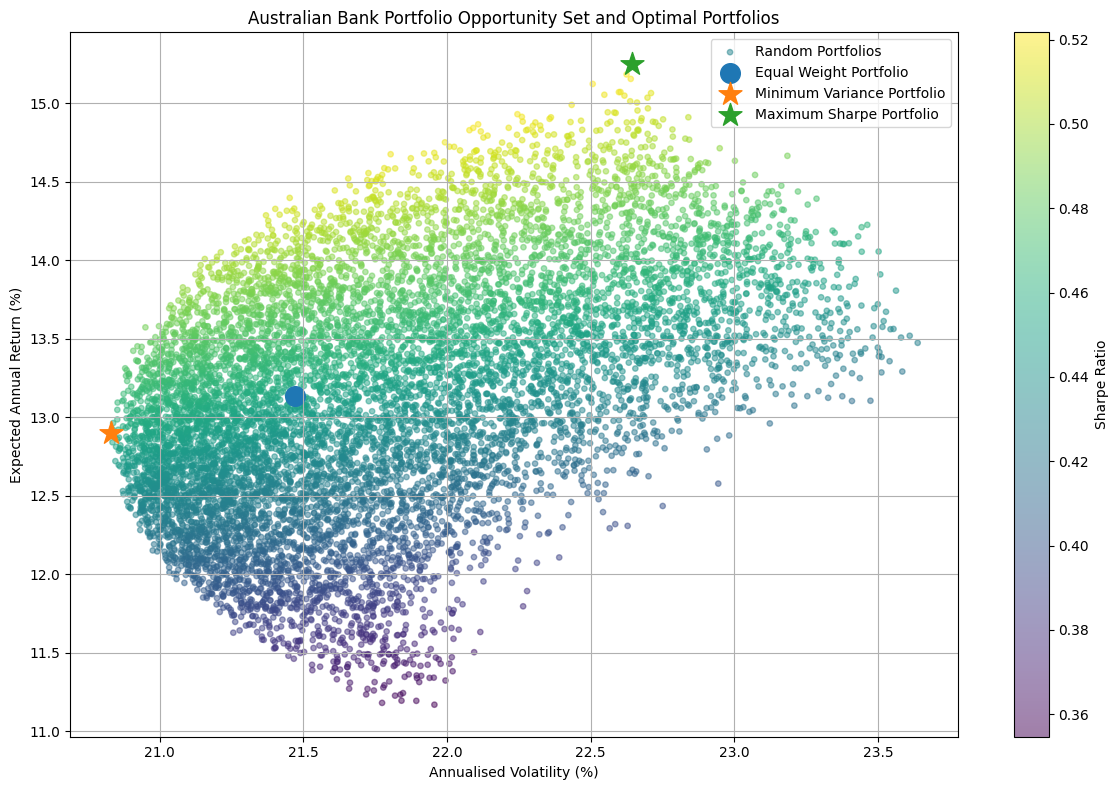

In [106]:
plt.figure(figsize=(12, 8))
plt.scatter(
    random_portfolios[
        "Annual_Volatility"
    ] * 100,

    random_portfolios[
        "Annual_Return"
    ] * 100,

    c=random_portfolios[
        "Sharpe_Ratio"
    ],
    cmap="viridis",
    alpha=0.5,
    s=15,
    label="Random Portfolios"
)

plt.colorbar(
    label="Sharpe Ratio"
)

plt.scatter(
    equal_weight_annual_volatility * 100,
    equal_weight_annual_return * 100,

    marker="o",
    s=200,
    label="Equal Weight Portfolio"
)

plt.scatter(
  minimum_variance_volatility * 100,
  minimum_variance_return * 100,
    marker="*",
    s=300,
    label="Minimum Variance Portfolio"
)

plt.scatter(
    maximum_sharpe_volatility * 100,
    maximum_sharpe_return * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.xlabel(
    "Annualised Volatility (%)"
)
plt.ylabel(
    "Expected Annual Return (%)"
)
plt.title(
    "Australian Bank Portfolio Opportunity Set and Optimal Portfolios"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../figures/opportunity_set_optimal_portfolios.png",
    dpi=300
)
plt.show()

In [107]:
portfolio_weights_table = pd.DataFrame({
    "Bank": banks,
    "Equal Weight":
        equal_weights,
    "Minimum Variance":
        minimum_variance_weights,
    "Maximum Sharpe":
        maximum_sharpe_weights
})

portfolio_weights_table = (
    portfolio_weights_table.set_index(
        "Bank"
    )
)
print(
    (portfolio_weights_table * 100).round(2)
)

      Equal Weight  Minimum Variance  Maximum Sharpe
Bank                                                
CBA           20.0             40.00           40.00
NAB           20.0             18.05            0.00
WBC           20.0             23.37           19.97
ANZ           20.0             12.88            0.03
MQG           20.0              5.69           40.00


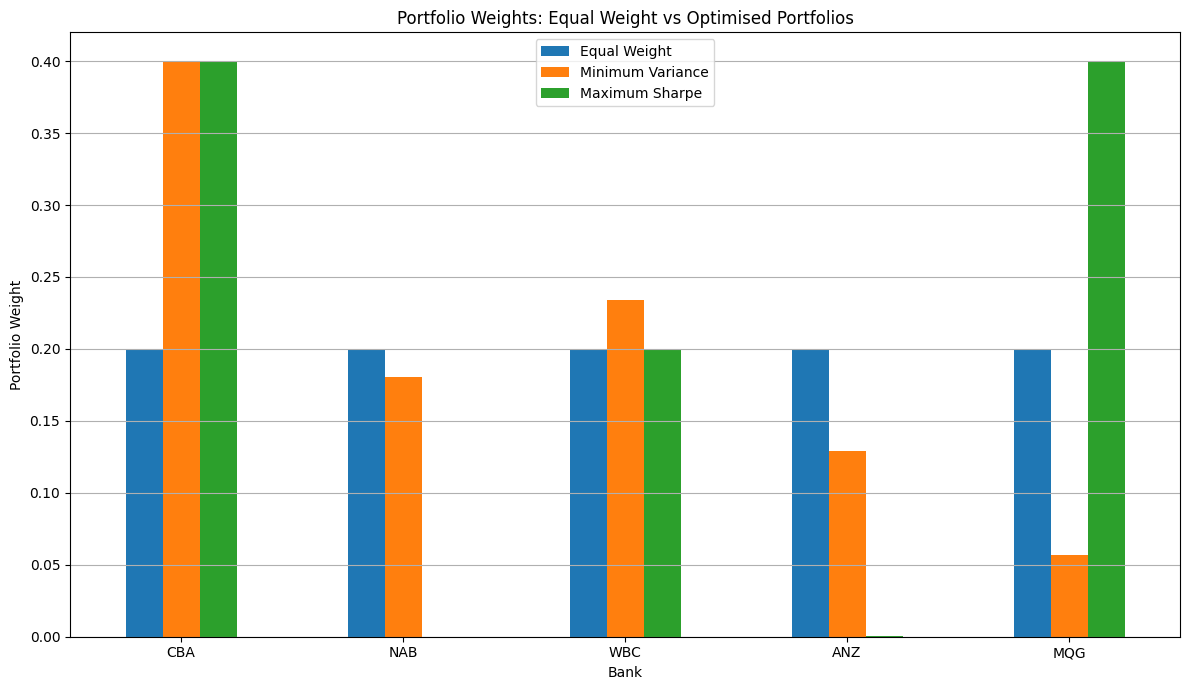

In [108]:
portfolio_weights_table.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Portfolio Weights: Equal Weight vs Optimised Portfolios"
)

plt.xlabel(
    "Bank"
)

plt.ylabel(
    "Portfolio Weight"
)

plt.xticks(
    rotation=0
)

plt.legend()
plt.grid(
    axis="y"
)
plt.tight_layout()
plt.savefig(
    "../figures/portfolio_weights.png",
    dpi=300
)
plt.show()

In [109]:
minimum_variance_returns = returns.dot(
    minimum_variance_weights
)

maximum_sharpe_returns = returns.dot(
    maximum_sharpe_weights
)

portfolio_daily_returns = pd.DataFrame({
    "Equal Weight":
        equal_weight_portfolio_returns,
    "Minimum Variance":
        minimum_variance_returns,
    "Maximum Sharpe":
        maximum_sharpe_returns
})

print(
    portfolio_daily_returns.head()
)

            Equal Weight  Minimum Variance  Maximum Sharpe
Date                                                      
2001-07-31     -0.003349         -0.007446       -0.001632
2001-08-01      0.017832          0.024501        0.007406
2001-08-02      0.012394          0.009213        0.015065
2001-08-03      0.003402         -0.002758       -0.005781
2001-08-06      0.005979          0.008455        0.011884


In [110]:
cumulative_portfolio_returns = (
    1 + portfolio_daily_returns
).cumprod()

print(
    cumulative_portfolio_returns.tail()
)

            Equal Weight  Minimum Variance  Maximum Sharpe
Date                                                      
2026-07-22     14.751658         14.325016       23.747642
2026-07-23     14.832402         14.416681       23.776621
2026-07-24     15.003040         14.588994       23.985359
2026-07-27     15.191259         14.773895       24.276267
2026-07-28     15.295456         14.925865       24.414571


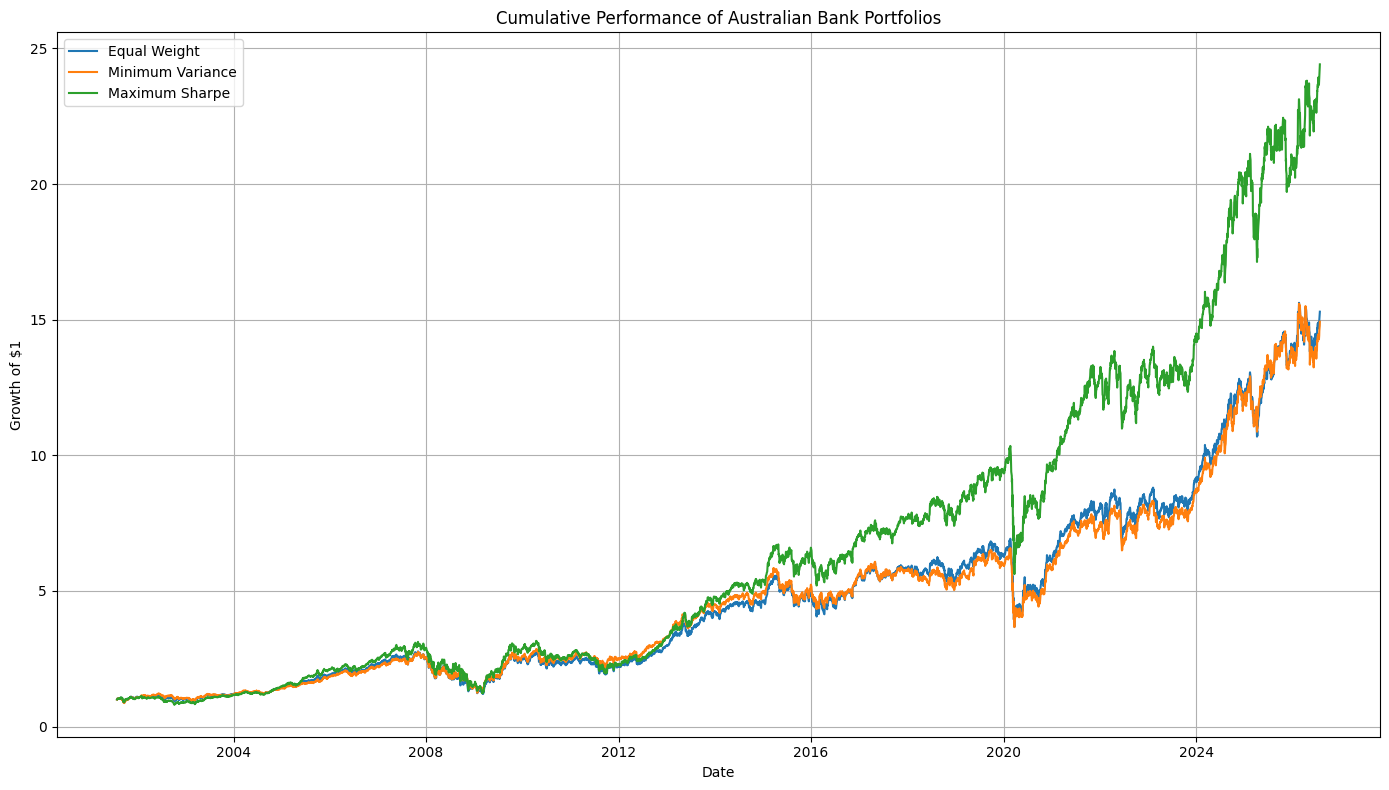

In [111]:
plt.figure(figsize=(14, 8))
for portfolio in cumulative_portfolio_returns.columns:

    plt.plot(
        cumulative_portfolio_returns.index,
        cumulative_portfolio_returns[
            portfolio
        ],
        label=portfolio
    )

plt.title(
    "Cumulative Performance of Australian Bank Portfolios"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Growth of $1"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../figures/cumulative_portfolio_performance.png",
    dpi=300
)
plt.show()

In [112]:
running_max = (
    cumulative_portfolio_returns.cummax()
)

drawdowns = (
    cumulative_portfolio_returns
    /
    running_max
    - 1
)
print(
    drawdowns.tail()
)

            Equal Weight  Minimum Variance  Maximum Sharpe
Date                                                      
2026-07-22     -0.055762         -0.081178       -0.007680
2026-07-23     -0.050593         -0.075299       -0.006469
2026-07-24     -0.039671         -0.064246        0.000000
2026-07-27     -0.027623         -0.052386        0.000000
2026-07-28     -0.020954         -0.042639        0.000000


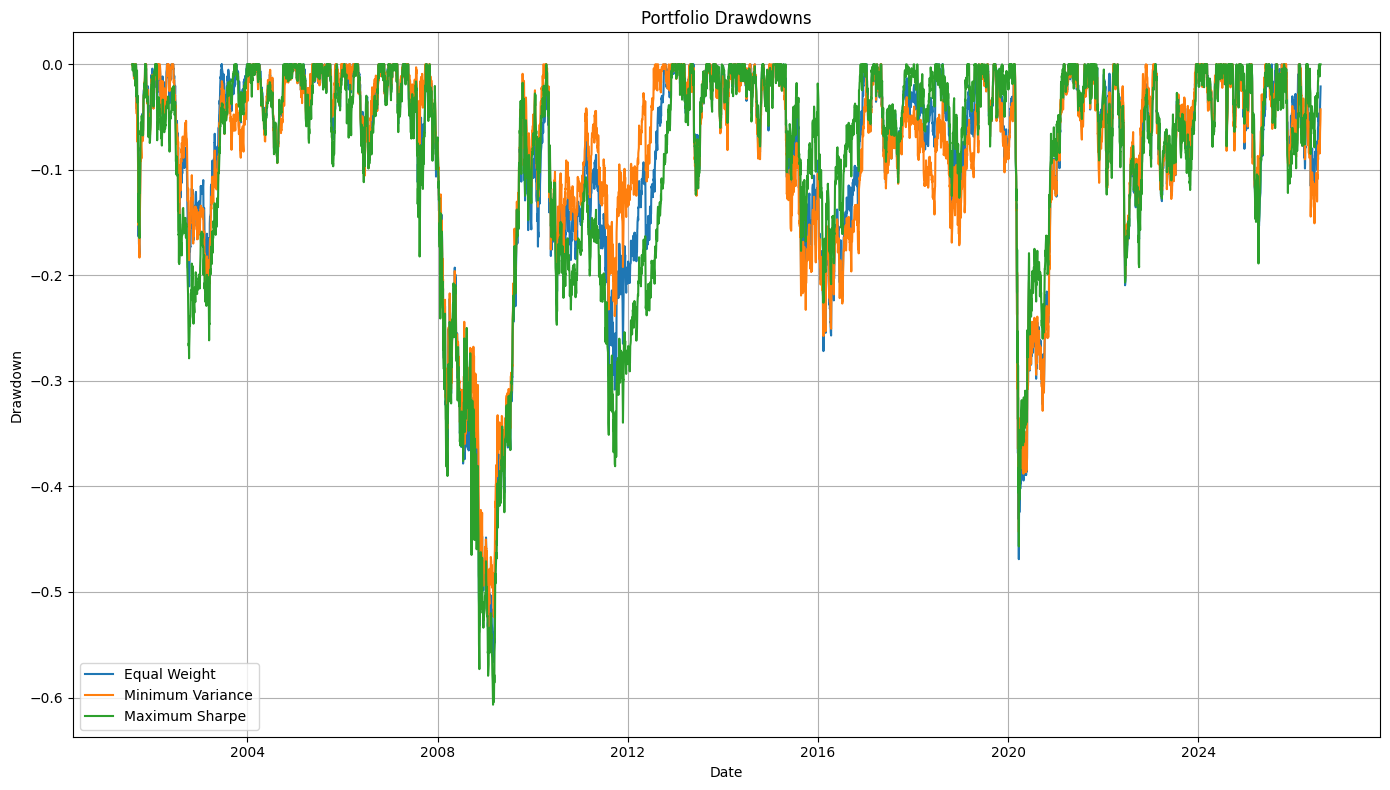

In [113]:
plt.figure(figsize=(14, 8))
for portfolio in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[
            portfolio
        ],
        label=portfolio
    )

plt.title(
    "Portfolio Drawdowns"
)
plt.xlabel(
    "Date"
)
plt.ylabel(
    "Drawdown"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../figures/portfolio_drawdowns.png",
    dpi=300
)
plt.show()

In [114]:
maximum_drawdowns = drawdowns.min()
maximum_drawdown_table = pd.DataFrame({
   "Maximum_Drawdown":
     maximum_drawdowns
})
print(
    (maximum_drawdown_table * 100).round(2)
)

                  Maximum_Drawdown
Equal Weight                -56.64
Minimum Variance            -54.88
Maximum Sharpe              -60.68


In [115]:
final_portfolio_summary = optimized_portfolio_results.copy()
final_portfolio_summary["Maximum_Drawdown"] = [
    maximum_drawdowns[
        "Equal Weight"
    ],
    maximum_drawdowns[
        "Minimum Variance"
    ],
    maximum_drawdowns[
        "Maximum Sharpe"
    ]
]

print(
    final_portfolio_summary.round(4)
)

                  Annual_Return  Annual_Volatility  Sharpe_Ratio  \
Equal Weight             0.1313             0.2147        0.4542   
Minimum Variance         0.1290             0.2083        0.4570   
Maximum Sharpe           0.1525             0.2264        0.5241   

                  Maximum_Drawdown  
Equal Weight               -0.5664  
Minimum Variance           -0.5488  
Maximum Sharpe             -0.6068  


In [116]:
def minimum_volatility_for_target_return(
    target_return
):
    constraints_frontier = [
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },

        {
            "type": "eq",
            "fun": lambda weights:
                np.dot(
                    weights,
                    annual_returns
                ) - target_return
        }
    ]

    result = minimize(
        portfolio_volatility_function,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_frontier
    )

    return result

In [117]:
min_return = annual_returns.min()
max_return = annual_returns.max()

target_returns = np.linspace(
    min_return,
    max_return,
    100
)

print(
    "Minimum Target Return:",
    format(min_return, ".2%")
)

print(
    "Maximum Target Return:",
    format(max_return, ".2%")
)

Minimum Target Return: 9.61%
Maximum Target Return: 17.56%


In [118]:
efficient_frontier_returns = []
efficient_frontier_volatility = []

for target_return in target_returns:

    result = minimum_volatility_for_target_return(
        target_return
    )
    if result.success:
        efficient_frontier_returns.append(
            target_return
        )
        efficient_frontier_volatility.append(
            result.fun
        )

print(
    "Number of Efficient Frontier Portfolios:",
    len(efficient_frontier_returns)
)

Number of Efficient Frontier Portfolios: 53


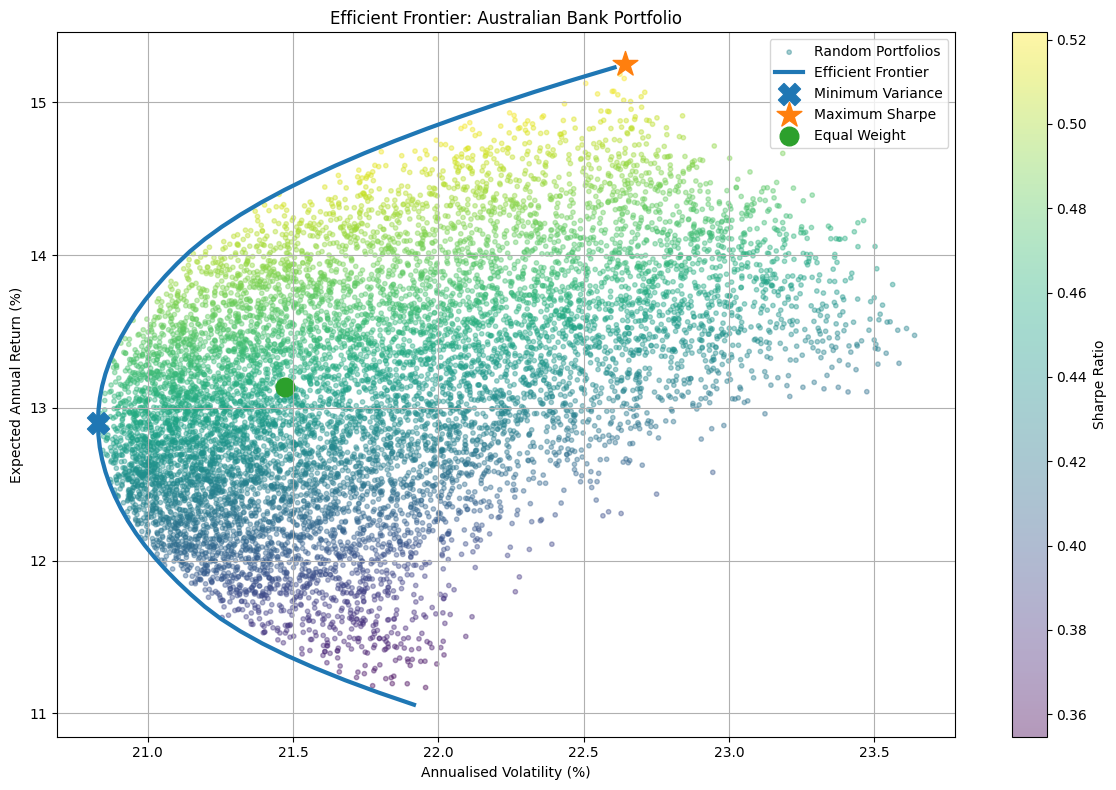

In [119]:
plt.figure(figsize=(12, 8))
plt.scatter(
    random_portfolios["Annual_Volatility"] * 100,
    random_portfolios["Annual_Return"] * 100,
    c=random_portfolios["Sharpe_Ratio"],
    cmap="viridis",
    alpha=0.4,
    s=10,
    label="Random Portfolios"
)

plt.colorbar(
    label="Sharpe Ratio"
)

plt.plot(
    np.array(
        efficient_frontier_volatility
    ) * 100,

    np.array(
        efficient_frontier_returns
    ) * 100,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    minimum_variance_volatility * 100,
    minimum_variance_return * 100,
    marker="X",
    s=250,
    label="Minimum Variance"
)

plt.scatter(
    maximum_sharpe_volatility * 100,
    maximum_sharpe_return * 100,
    marker="*",
    s=350,
    label="Maximum Sharpe"
)

plt.scatter(
    equal_weight_annual_volatility * 100,
    equal_weight_annual_return * 100,
    marker="o",
    s=180,
    label="Equal Weight"
)

plt.xlabel(
    "Annualised Volatility (%)"
)

plt.ylabel(
    "Expected Annual Return (%)"
)

plt.title(
    "Efficient Frontier: Australian Bank Portfolio"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "../figures/efficient_frontier.png",
    dpi=300
)

plt.show()

In [120]:
portfolio_daily_returns = pd.DataFrame(
    index=returns.index
)
portfolio_daily_returns[
    "Equal Weight"
] = equal_weight_portfolio_returns

portfolio_daily_returns[
    "Minimum Variance"
] = returns.dot(
    minimum_variance_weights
)
portfolio_daily_returns[
    "Maximum Sharpe"
] = returns.dot(
    maximum_sharpe_weights
)
print(
    portfolio_daily_returns.head()
)
print(
    "\nPortfolio dataset shape:"
)

print(
    portfolio_daily_returns.shape
)

            Equal Weight  Minimum Variance  Maximum Sharpe
Date                                                      
2001-07-31     -0.003349         -0.007446       -0.001632
2001-08-01      0.017832          0.024501        0.007406
2001-08-02      0.012394          0.009213        0.015065
2001-08-03      0.003402         -0.002758       -0.005781
2001-08-06      0.005979          0.008455        0.011884

Portfolio dataset shape:
(6348, 3)


In [121]:
print(
    "MISSING VALUES:"
)

print(
    portfolio_daily_returns.isnull().sum()
)

print(
    "\nDATE RANGE:"
)

print(
    "Start:",
    portfolio_daily_returns.index.min()
)

print(
    "End:",
    portfolio_daily_returns.index.max()
)

MISSING VALUES:
Equal Weight        0
Minimum Variance    0
Maximum Sharpe      0
dtype: int64

DATE RANGE:
Start: 2001-07-31 00:00:00
End: 2026-07-28 00:00:00


In [122]:
crisis_periods = {
    "GFC": (
        "2007-10-01",
        "2009-03-31"
    ),

    "COVID": (
        "2020-02-19",
        "2021-06-30"
    ),

    "Rate Hikes": (
        "2022-05-03",
        "2023-11-07"
    )
}
for period, dates in crisis_periods.items():

    print(
        period,
        ":",
        dates
    )

GFC : ('2007-10-01', '2009-03-31')
COVID : ('2020-02-19', '2021-06-30')
Rate Hikes : ('2022-05-03', '2023-11-07')


In [123]:
daily_rf_return = pd.Series(
    annual_risk_free_rate / 252,
    index=returns.index,
    name="Daily_Risk_Free_Return"
)

print(daily_rf_return.head())
print("\nMissing values:")
print(daily_rf_return.isna().sum())

Date
2001-07-31    0.000134
2001-08-01    0.000134
2001-08-02    0.000134
2001-08-03    0.000134
2001-08-06    0.000134
Name: Daily_Risk_Free_Return, dtype: float64

Missing values:
0


In [124]:
def calculate_crisis_performance(
    portfolio_returns
):
    total_return = (
        1 + portfolio_returns
    ).prod() - 1
    annual_return = (
        1 + total_return
    ) ** (
        252 / len(portfolio_returns)
    ) - 1
    annual_volatility = (
        portfolio_returns.std()
        * np.sqrt(252)
    )
    excess_returns = (
        portfolio_returns
        - daily_rf_return.reindex(
            portfolio_returns.index
        )
    )

    sharpe_ratio = (
        excess_returns.mean()
        /
        portfolio_returns.std()
    ) * np.sqrt(252)

    cumulative_returns = (
        1 + portfolio_returns
    ).cumprod()

    running_max = (
        cumulative_returns.cummax()
    )

    drawdown = (
        cumulative_returns
        /
        running_max
    ) - 1

    maximum_drawdown = (
        drawdown.min()

    )
    return {
        "Total Return": total_return,
        "Annualised Return": annual_return,
        "Annualised Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }

In [125]:
crisis_results = []
for crisis, (
    start_date,
    end_date

) in crisis_periods.items():
    crisis_data = (
        portfolio_daily_returns.loc[
            start_date:end_date
        ]
    )
    for portfolio in crisis_data.columns:
        performance = (
            calculate_crisis_performance(
                crisis_data[
                    portfolio
                ]
            )
        )
        crisis_results.append({
            "Period": crisis,
            "Portfolio": portfolio,
            **performance
        })
crisis_performance_table = pd.DataFrame(
    crisis_results
)
print(
    crisis_performance_table.round(4)
)

       Period         Portfolio  Total Return  Annualised Return  \
0         GFC      Equal Weight       -0.3941            -0.2827   
1         GFC  Minimum Variance       -0.3421            -0.2424   
2         GFC    Maximum Sharpe       -0.4193            -0.3026   
3       COVID      Equal Weight        0.1031             0.0740   
4       COVID  Minimum Variance        0.1106             0.0794   
5       COVID    Maximum Sharpe        0.1343             0.0962   
6  Rate Hikes      Equal Weight       -0.0251            -0.0164   
7  Rate Hikes  Minimum Variance        0.0020             0.0013   
8  Rate Hikes    Maximum Sharpe       -0.0518            -0.0341   

   Annualised Volatility  Sharpe Ratio  Maximum Drawdown  
0                 0.4652       -0.5569           -0.5664  
1                 0.4300       -0.5111           -0.5488  
2                 0.5097       -0.5217           -0.6068  
3                 0.3682        0.2882           -0.4689  
4                 0.3639

In [126]:
crisis_results_percent = (
    crisis_performance_table.copy()
)
percentage_columns = [
    "Total Return",
    "Annualised Return",
    "Annualised Volatility",
    "Maximum Drawdown"
]
for column in percentage_columns:
    crisis_results_percent[column] = (
        crisis_results_percent[column]
        * 100
    )
    
print(
    crisis_results_percent.round(2)
)

       Period         Portfolio  Total Return  Annualised Return  \
0         GFC      Equal Weight        -39.41             -28.27   
1         GFC  Minimum Variance        -34.21             -24.24   
2         GFC    Maximum Sharpe        -41.93             -30.26   
3       COVID      Equal Weight         10.31               7.40   
4       COVID  Minimum Variance         11.06               7.94   
5       COVID    Maximum Sharpe         13.43               9.62   
6  Rate Hikes      Equal Weight         -2.51              -1.64   
7  Rate Hikes  Minimum Variance          0.20               0.13   
8  Rate Hikes    Maximum Sharpe         -5.18              -3.41   

   Annualised Volatility  Sharpe Ratio  Maximum Drawdown  
0                  46.52         -0.56            -56.64  
1                  43.00         -0.51            -54.88  
2                  50.97         -0.52            -60.68  
3                  36.82          0.29            -46.89  
4                  36.39

In [127]:
crisis_summary = (
    crisis_results_percent.pivot(
        index="Period",
        columns="Portfolio",
        values="Total Return"
    )
)
print(
    "TOTAL RETURN BY PERIOD (%)"
)
print(
    crisis_summary.round(2)
)

TOTAL RETURN BY PERIOD (%)
Portfolio   Equal Weight  Maximum Sharpe  Minimum Variance
Period                                                    
COVID              10.31           13.43             11.06
GFC               -39.41          -41.93            -34.21
Rate Hikes         -2.51           -5.18              0.20


In [128]:
crisis_results_percent_display = (
    crisis_results_percent.copy()
)

print(
    crisis_results_percent_display.round(2)
)


       Period         Portfolio  Total Return  Annualised Return  \
0         GFC      Equal Weight        -39.41             -28.27   
1         GFC  Minimum Variance        -34.21             -24.24   
2         GFC    Maximum Sharpe        -41.93             -30.26   
3       COVID      Equal Weight         10.31               7.40   
4       COVID  Minimum Variance         11.06               7.94   
5       COVID    Maximum Sharpe         13.43               9.62   
6  Rate Hikes      Equal Weight         -2.51              -1.64   
7  Rate Hikes  Minimum Variance          0.20               0.13   
8  Rate Hikes    Maximum Sharpe         -5.18              -3.41   

   Annualised Volatility  Sharpe Ratio  Maximum Drawdown  
0                  46.52         -0.56            -56.64  
1                  43.00         -0.51            -54.88  
2                  50.97         -0.52            -60.68  
3                  36.82          0.29            -46.89  
4                  36.39

In [129]:
crisis_comparison = crisis_results_percent[
    [
        "Period",
        "Portfolio",
        "Total Return",
        "Annualised Return",
        "Annualised Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
].copy()

print(
    crisis_comparison.round(2)
)

       Period         Portfolio  Total Return  Annualised Return  \
0         GFC      Equal Weight        -39.41             -28.27   
1         GFC  Minimum Variance        -34.21             -24.24   
2         GFC    Maximum Sharpe        -41.93             -30.26   
3       COVID      Equal Weight         10.31               7.40   
4       COVID  Minimum Variance         11.06               7.94   
5       COVID    Maximum Sharpe         13.43               9.62   
6  Rate Hikes      Equal Weight         -2.51              -1.64   
7  Rate Hikes  Minimum Variance          0.20               0.13   
8  Rate Hikes    Maximum Sharpe         -5.18              -3.41   

   Annualised Volatility  Sharpe Ratio  Maximum Drawdown  
0                  46.52         -0.56            -56.64  
1                  43.00         -0.51            -54.88  
2                  50.97         -0.52            -60.68  
3                  36.82          0.29            -46.89  
4                  36.39

In [130]:
drawdown_comparison = (
    crisis_results_percent.pivot(
        index="Period",
        columns="Portfolio",
        values="Maximum Drawdown"
    )
)

print(
    "MAXIMUM DRAWDOWN BY PERIOD (%)"
)

print(
    drawdown_comparison.round(2)
)

MAXIMUM DRAWDOWN BY PERIOD (%)
Portfolio   Equal Weight  Maximum Sharpe  Minimum Variance
Period                                                    
COVID             -46.89          -45.68            -44.32
GFC               -56.64          -60.68            -54.88
Rate Hikes        -18.43          -17.77            -18.60


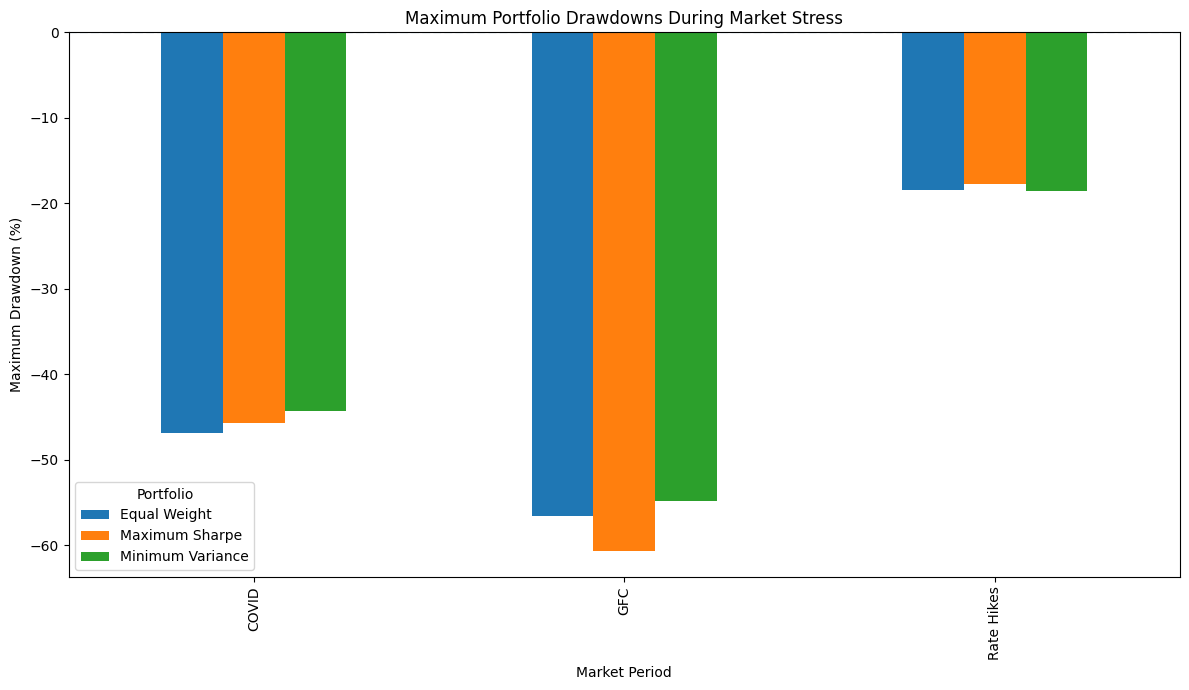

In [131]:
drawdown_comparison.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Maximum Portfolio Drawdowns During Market Stress"
)

plt.xlabel(
    "Market Period"
)

plt.ylabel(
    "Maximum Drawdown (%)"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.legend(
    title="Portfolio"
)

plt.tight_layout()
plt.savefig(
    "../figures/maximum_portfolio_drawdowns_market_stress.png",
    dpi=300
)
plt.show()

In [132]:
volatility_comparison = (
    crisis_results_percent.pivot(
        index="Period",
        columns="Portfolio",
        values="Annualised Volatility"
    )
)
print(
    "ANNUALISED VOLATILITY BY PERIOD (%)"
)

print(
    volatility_comparison.round(2)
)

ANNUALISED VOLATILITY BY PERIOD (%)
Portfolio   Equal Weight  Maximum Sharpe  Minimum Variance
Period                                                    
COVID              36.82           35.11             36.39
GFC                46.52           50.97             43.00
Rate Hikes         17.33           18.00             17.27


In [133]:
sharpe_comparison = (
    crisis_results_percent.pivot(
        index="Period",
        columns="Portfolio",
        values="Sharpe Ratio"
    )
)
print(
    "SHARPE RATIO BY PERIOD"
)

print(
    sharpe_comparison.round(3)
)

SHARPE RATIO BY PERIOD
Portfolio   Equal Weight  Maximum Sharpe  Minimum Variance
Period                                                    
COVID              0.288           0.343             0.300
GFC               -0.557          -0.522            -0.511
Rate Hikes        -0.204          -0.291            -0.102


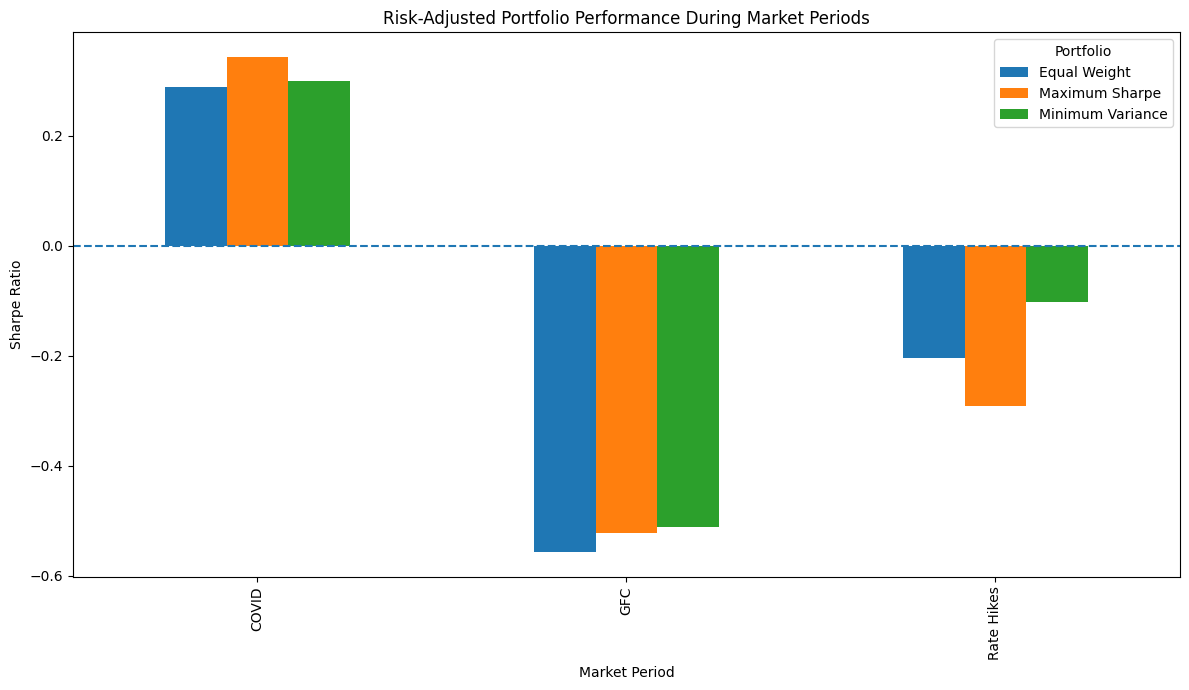

In [134]:
sharpe_comparison.plot(
    kind="bar",
    figsize=(12, 7)
)
plt.title(
    "Risk-Adjusted Portfolio Performance During Market Periods"
)

plt.xlabel(
    "Market Period"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.legend(
    title="Portfolio"
)

plt.tight_layout()
plt.savefig(
    "../figures/risk_adjusted_portfolio_performance_market_periods.png",
    dpi=300
)
plt.show()

In [135]:
train_returns = returns.loc[
    "2001-07-31":"2020-12-31"
].copy()

test_returns = returns.loc[
    "2021-01-01":"2026-07-28"
].copy()

print("TRAINING DATA")
print("Shape:", train_returns.shape)
print("Start:", train_returns.index.min())
print("End:", train_returns.index.max())

print("\nTESTING DATA")
print("Shape:", test_returns.shape)
print("Start:", test_returns.index.min())
print("End:", test_returns.index.max())

TRAINING DATA
Shape: (4940, 5)
Start: 2001-07-31 00:00:00
End: 2020-12-31 00:00:00

TESTING DATA
Shape: (1408, 5)
Start: 2021-01-04 00:00:00
End: 2026-07-28 00:00:00


In [136]:
training_annual_returns = train_returns.mean() * 252
training_annual_covariance = train_returns.cov() * 252

print("TRAINING ANNUALISED RETURNS:")
print(training_annual_returns.round(4))

print("\nTRAINING ANNUALISED COVARIANCE MATRIX:")
print(training_annual_covariance.round(4))

TRAINING ANNUALISED RETURNS:
CBA    0.1309
NAB    0.0739
WBC    0.1004
ANZ    0.1066
MQG    0.1764
dtype: float64

TRAINING ANNUALISED COVARIANCE MATRIX:
        CBA     NAB     WBC     ANZ     MQG
CBA  0.0500  0.0420  0.0423  0.0426  0.0418
NAB  0.0420  0.0629  0.0459  0.0495  0.0520
WBC  0.0423  0.0459  0.0591  0.0499  0.0454
ANZ  0.0426  0.0495  0.0499  0.0659  0.0504
MQG  0.0418  0.0520  0.0454  0.0504  0.1200


In [137]:
n_assets = len(banks)
bounds = tuple(
    (0, 0.40) for _ in range(n_assets)
)
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}
def training_portfolio_volatility(weights):
    return np.sqrt(
        weights.T
        @ training_annual_covariance.values
        @ weights
    )

initial_weights = np.ones(n_assets) / n_assets
min_variance_result_oos = minimize(
    training_portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_variance_weights_oos = min_variance_result_oos.x
training_risk_free_rate = annual_risk_free_rate

def training_negative_sharpe(weights):
    portfolio_return = (
        weights @ training_annual_returns.values
    )
    portfolio_volatility = np.sqrt(
        weights.T
        @ training_annual_covariance.values
        @ weights
    )
    return -(
        portfolio_return - training_risk_free_rate
    ) / portfolio_volatility


max_sharpe_result_oos = minimize(
    training_negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights_oos = max_sharpe_result_oos.x
print("MINIMUM-VARIANCE TRAINING WEIGHTS")

for bank, weight in zip(
    banks,
    min_variance_weights_oos
):
    print(bank + ": " + format(weight, ".2%"))


print("\nMAXIMUM-SHARPE TRAINING WEIGHTS")
for bank, weight in zip(
    banks,
    max_sharpe_weights_oos
):
    print(bank + ": " + format(weight, ".2%"))

MINIMUM-VARIANCE TRAINING WEIGHTS
CBA: 40.00%
NAB: 20.70%
WBC: 26.73%
ANZ: 8.90%
MQG: 3.66%

MAXIMUM-SHARPE TRAINING WEIGHTS
CBA: 40.00%
NAB: 0.00%
WBC: 8.39%
ANZ: 11.61%
MQG: 40.00%


In [138]:
equal_weights_oos = np.ones(n_assets) / n_assets
print("EQUAL WEIGHTS")

for bank, weight in zip(
    banks,
    equal_weights_oos
):
    print(bank + ": " + format(weight, ".2%"))

EQUAL WEIGHTS
CBA: 20.00%
NAB: 20.00%
WBC: 20.00%
ANZ: 20.00%
MQG: 20.00%


In [139]:
oos_portfolio_returns = pd.DataFrame(index=test_returns.index)
oos_portfolio_returns["Equal Weight"] = (
    test_returns @ equal_weights_oos
)

oos_portfolio_returns["Minimum Variance"] = (
    test_returns @ min_variance_weights_oos
)

oos_portfolio_returns["Maximum Sharpe"] = (
    test_returns @ max_sharpe_weights_oos
)

print(
    oos_portfolio_returns.head()
)

            Equal Weight  Minimum Variance  Maximum Sharpe
Date                                                      
2021-01-04      0.014790          0.016336        0.015245
2021-01-05     -0.006335         -0.006652       -0.005849
2021-01-06     -0.011182         -0.007798       -0.012651
2021-01-07      0.027500          0.026553        0.022920
2021-01-08      0.013379          0.013044        0.014388


In [140]:
oos_results = pd.DataFrame(
    index=oos_portfolio_returns.columns
)

oos_results["Annual_Return"] = (
    oos_portfolio_returns.mean() * 252
)

oos_results["Annual_Volatility"] = (
    oos_portfolio_returns.std() * np.sqrt(252)
)

oos_results["Sharpe_Ratio"] = (
    oos_results["Annual_Return"]
    - annual_risk_free_rate
) / oos_results["Annual_Volatility"]

print(
    oos_results.round(4)
)

                  Annual_Return  Annual_Volatility  Sharpe_Ratio
Equal Weight             0.1794             0.1674        0.8698
Minimum Variance         0.1865             0.1745        0.8748
Maximum Sharpe           0.1824             0.1752        0.8478


In [141]:
oos_cumulative_returns = (
    1 + oos_portfolio_returns
).cumprod()

print(
    oos_cumulative_returns.tail()
)

            Equal Weight  Minimum Variance  Maximum Sharpe
Date                                                      
2026-07-22      2.428896          2.494653        2.473286
2026-07-23      2.442191          2.511812        2.475783
2026-07-24      2.470287          2.542278        2.497672
2026-07-27      2.501277          2.574908        2.527091
2026-07-28      2.518434          2.602004        2.541465


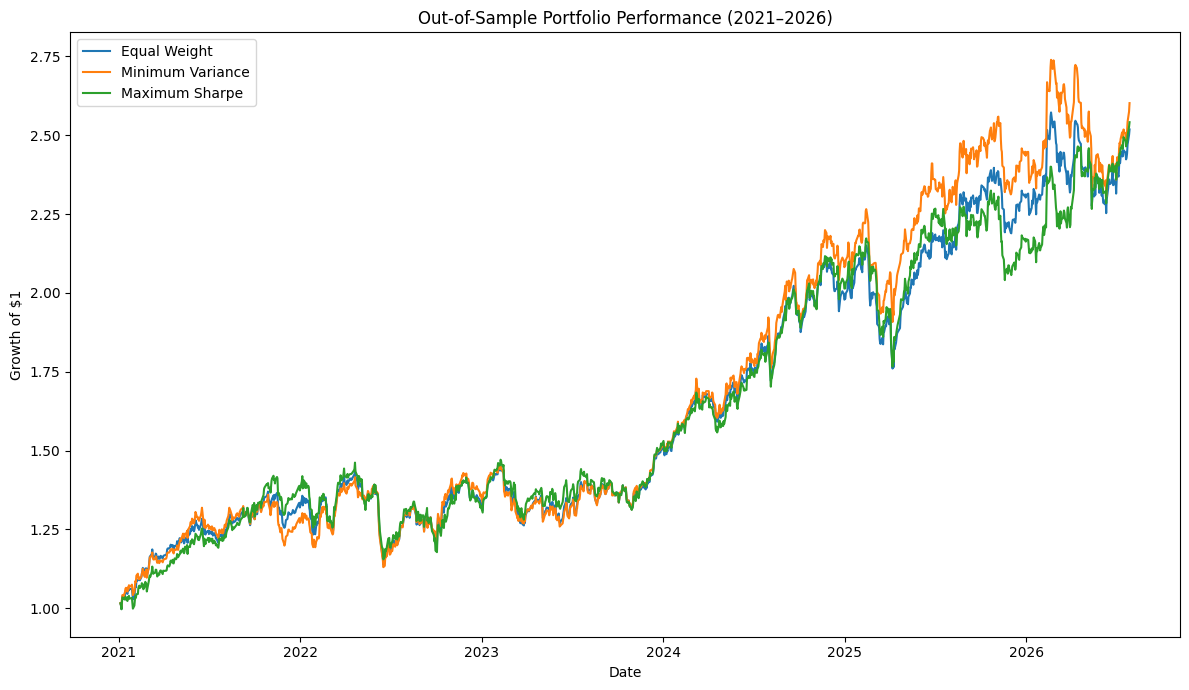

In [142]:
plt.figure(figsize=(12, 7))
for portfolio in oos_cumulative_returns.columns:

    plt.plot(
        oos_cumulative_returns.index,
        oos_cumulative_returns[portfolio],
        label=portfolio
    )

plt.title(
    "Out-of-Sample Portfolio Performance (2021–2026)"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../figures/oos_portfolio_performance_2021_2026.png",
    dpi=300
)
plt.show()

In [143]:
oos_drawdowns = pd.DataFrame(
    index=oos_cumulative_returns.index
)
for portfolio in oos_cumulative_returns.columns:

    running_max = (
        oos_cumulative_returns[portfolio]
        .cummax()
    )

    oos_drawdowns[portfolio] = (
        oos_cumulative_returns[portfolio]
        / running_max
        - 1
    )

print(
    oos_drawdowns.min().round(4)
)

Equal Weight       -0.2093
Minimum Variance   -0.2016
Maximum Sharpe     -0.2099
dtype: float64


In [144]:
oos_results_display = oos_results.copy()
oos_results_display[
    "Annual_Return"
] *= 100
oos_results_display[
    "Annual_Volatility"
] *= 100
oos_results_display = oos_results_display.round(2)
print(
    oos_results_display
)

                  Annual_Return  Annual_Volatility  Sharpe_Ratio
Equal Weight              17.94              16.74          0.87
Minimum Variance          18.65              17.45          0.87
Maximum Sharpe            18.24              17.52          0.85


In [145]:
n_assets = len(banks)
initial_weights = np.ones(n_assets) / n_assets
constraints = {
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
}

bounds = [(0, 0.40) for _ in range(n_assets)]
def portfolio_variance(w):
    return np.dot(w, np.dot(annual_covariance, w))

min_var_result = minimize(
    portfolio_variance,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var_result.x
def negative_sharpe(w):
    portfolio_return = np.dot(w, annual_returns)
    portfolio_volatility = np.sqrt(
        np.dot(w, np.dot(annual_covariance, w))
    )
    
    sharpe = (
        portfolio_return - annual_risk_free_rate
    ) / portfolio_volatility
    
    return -sharpe


max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe_result.x


print("Optimisation successful:")
print("Minimum Variance:", min_var_result.success)
print("Maximum Sharpe:", max_sharpe_result.success)

print("\nMinimum Variance Weights:")
for bank, weight in zip(banks, min_var_weights):
    print(bank + ": " + format(weight, ".6%"))

print("\nMaximum Sharpe Weights:")
for bank, weight in zip(banks, max_sharpe_weights):
    print(bank + ": " + format(weight, ".6%"))

Optimisation successful:
Minimum Variance: True
Maximum Sharpe: True

Minimum Variance Weights:
CBA: 40.000000%
NAB: 18.039391%
WBC: 21.904347%
ANZ: 14.396481%
MQG: 5.659781%

Maximum Sharpe Weights:
CBA: 40.000000%
NAB: 0.000000%
WBC: 19.972244%
ANZ: 0.027756%
MQG: 40.000000%


In [146]:
print("Minimum Variance Weights:")
for bank, weight in zip(banks, min_var_weights):
    print(bank + ": " + format(weight, ".6f") + " (" + format(weight, ".2%") + ")")

print("\nMaximum Sharpe Weights:")
for bank, weight in zip(banks, max_sharpe_weights):
    print(bank + ": " + format(weight, ".6f") + " (" + format(weight, ".2%") + ")")

Minimum Variance Weights:
CBA: 0.400000 (40.00%)
NAB: 0.180394 (18.04%)
WBC: 0.219043 (21.90%)
ANZ: 0.143965 (14.40%)
MQG: 0.056598 (5.66%)

Maximum Sharpe Weights:
CBA: 0.400000 (40.00%)
NAB: 0.000000 (0.00%)
WBC: 0.199722 (19.97%)
ANZ: 0.000278 (0.03%)
MQG: 0.400000 (40.00%)


In [147]:
def check_constraints(weights, portfolio_name):
    print("\n" + portfolio_name)
    
    print("Weight sum: " + format(weights.sum(), ".12f"))
    print("Minimum weight: " + format(weights.min(), ".6f"))
    print("Maximum weight: " + format(weights.max(), ".6f"))
    
    print("Sum equals 1: " + str(np.isclose(weights.sum(), 1.0)))
    print("No negative weights: " + str((weights >= 0).all()))
    print("No weight above 40%: " + str((weights <= 0.40).all()))

check_constraints(min_var_weights, "Minimum Variance Portfolio")
check_constraints(max_sharpe_weights, "Maximum Sharpe Portfolio")


Minimum Variance Portfolio
Weight sum: 1.000000000000
Minimum weight: 0.056598
Maximum weight: 0.400000
Sum equals 1: True
No negative weights: True
No weight above 40%: True

Maximum Sharpe Portfolio
Weight sum: 1.000000000000
Minimum weight: 0.000000
Maximum weight: 0.400000
Sum equals 1: True
No negative weights: True
No weight above 40%: True


In [148]:
min_var_return_check = np.dot(min_var_weights, annual_returns)
max_sharpe_return_check = np.dot(max_sharpe_weights, annual_returns)

print("Minimum Variance Return:")
print(format(min_var_return_check, ".6%"))

print("\nMaximum Sharpe Return:")
print(format(max_sharpe_return_check, ".6%"))

Minimum Variance Return:
12.897694%

Maximum Sharpe Return:
15.248790%


In [149]:
min_var_vol_check = np.sqrt(
    np.dot(min_var_weights, np.dot(annual_covariance, min_var_weights))
)

max_sharpe_vol_check = np.sqrt(
    np.dot(max_sharpe_weights, np.dot(annual_covariance, max_sharpe_weights))
)

print("Minimum Variance Volatility:")
print(format(min_var_vol_check, ".6%"))

print("\nMaximum Sharpe Volatility:")
print(format(max_sharpe_vol_check, ".6%"))

Minimum Variance Volatility:
20.830245%

Maximum Sharpe Volatility:
22.642702%


In [150]:
min_var_sharpe_check = (
    min_var_return_check - annual_risk_free_rate
) / min_var_vol_check

max_sharpe_sharpe_check = (
    max_sharpe_return_check - annual_risk_free_rate
) / max_sharpe_vol_check

print("Minimum Variance Sharpe Ratio:")
print(format(min_var_sharpe_check, ".6f"))

print("\nMaximum Sharpe Sharpe Ratio:")
print(format(max_sharpe_sharpe_check, ".6f"))

Minimum Variance Sharpe Ratio:
0.456816

Maximum Sharpe Sharpe Ratio:
0.524084


In [151]:
print("Annual Risk-Free Rate:")
print(format(annual_risk_free_rate, ".10%"))

print("\nAnnual Returns:")
print(annual_returns)

print("\nAnnual Covariance Matrix:")
print(annual_covariance)

print("\nCurrent Minimum Variance Weights:")
for bank, weight in zip(banks, min_var_weights):
    print(bank + ": " + format(weight, ".6%"))

print("\nCurrent Maximum Sharpe Weights:")
for bank, weight in zip(banks, max_sharpe_weights):
    print(bank + ": " + format(weight, ".6%"))

Annual Risk-Free Rate:
3.3821144495%

Annual Returns:
CBA    0.145326
NAB    0.096125
WBC    0.120684
ANZ    0.119024
MQG    0.175553
dtype: float64

Annual Covariance Matrix:
          CBA       NAB       WBC       ANZ       MQG
CBA  0.048180  0.038762  0.038884  0.038509  0.037119
NAB  0.038762  0.057352  0.042279  0.044288  0.045310
WBC  0.038884  0.042279  0.054606  0.044944  0.040021
ANZ  0.038509  0.044288  0.044944  0.059156  0.043792
MQG  0.037119  0.045310  0.040021  0.043792  0.105460

Current Minimum Variance Weights:
CBA: 40.000000%
NAB: 18.039391%
WBC: 21.904347%
ANZ: 14.396481%
MQG: 5.659781%

Current Maximum Sharpe Weights:
CBA: 40.000000%
NAB: 0.000000%
WBC: 19.972244%
ANZ: 0.027756%
MQG: 40.000000%


In [152]:
print("Minimum Variance Optimisation")
print("Success:", min_var_result.success)
print("Message:", min_var_result.message)
print("Objective value:", min_var_result.fun)

print("\nMaximum Sharpe Optimisation")
print("Success:", max_sharpe_result.success)
print("Message:", max_sharpe_result.message)
print("Objective value:", max_sharpe_result.fun)

print("\nMaximum Sharpe calculated:")
print(format(max_sharpe_sharpe_check, ".6f"))

Minimum Variance Optimisation
Success: True
Message: Optimization terminated successfully
Objective value: 0.04338991170514003

Maximum Sharpe Optimisation
Success: True
Message: Optimization terminated successfully
Objective value: -0.5240838971984858

Maximum Sharpe calculated:
0.524084


In [153]:
starting_weights_list = [
    np.array([0.20, 0.20, 0.20, 0.20, 0.20]),
    np.array([0.40, 0.15, 0.15, 0.15, 0.15]),
    np.array([0.15, 0.40, 0.15, 0.15, 0.15]),
    np.array([0.10, 0.10, 0.40, 0.20, 0.10]),
    np.array([0.10, 0.10, 0.10, 0.30, 0.40])
]

multi_start_results = []
for i, starting_weights in enumerate(starting_weights_list, start=1):    
    result = minimize(
        negative_sharpe,
        starting_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    
    multi_start_results.append(result)  
    weights = result.x    
    portfolio_return = np.dot(weights, annual_returns)    
    portfolio_volatility = np.sqrt(
        np.dot(weights, np.dot(annual_covariance, weights))
    )
    
    sharpe = (
        portfolio_return - annual_risk_free_rate
    ) / portfolio_volatility
    
    print("\nStarting Portfolio " + str(i))
    print("----------------------")
    print("Success:", result.success)
    print("Sharpe:", format(sharpe, ".6f"))
    
    print("Weights:")
    for bank, weight in zip(banks, weights):
        print("  " + bank + ": " + format(weight, ".6%"))


Starting Portfolio 1
----------------------
Success: True
Sharpe: 0.524084
Weights:
  CBA: 40.000000%
  NAB: 0.000000%
  WBC: 19.972244%
  ANZ: 0.027756%
  MQG: 40.000000%

Starting Portfolio 2
----------------------
Success: True
Sharpe: 0.524084
Weights:
  CBA: 40.000000%
  NAB: 0.000000%
  WBC: 20.000000%
  ANZ: 0.000000%
  MQG: 40.000000%

Starting Portfolio 3
----------------------
Success: True
Sharpe: 0.524084
Weights:
  CBA: 40.000000%
  NAB: 0.000000%
  WBC: 20.000000%
  ANZ: 0.000000%
  MQG: 40.000000%

Starting Portfolio 4
----------------------
Success: True
Sharpe: 0.524084
Weights:
  CBA: 40.000000%
  NAB: 0.000000%
  WBC: 20.000000%
  ANZ: 0.000000%
  MQG: 40.000000%

Starting Portfolio 5
----------------------
Success: True
Sharpe: 0.524084
Weights:
  CBA: 40.000000%
  NAB: 0.000000%
  WBC: 20.000000%
  ANZ: 0.000000%
  MQG: 40.000000%


In [154]:
np.random.seed(42)
n_random_portfolios = 10000
random_weights = []
random_returns = []
random_volatilities = []
random_sharpes = []

while len(random_weights) < n_random_portfolios:
    weights = np.random.dirichlet(np.ones(len(banks)))
    if np.all(weights <= 0.40):
        portfolio_return = np.dot(
            weights,
            annual_returns
        )
        portfolio_volatility = np.sqrt(
            np.dot(
                weights,
                np.dot(annual_covariance, weights)
            )
        )
        portfolio_sharpe = (
            portfolio_return - annual_risk_free_rate
        ) / portfolio_volatility

        random_weights.append(weights)
        random_returns.append(portfolio_return)
        random_volatilities.append(portfolio_volatility)
        random_sharpes.append(portfolio_sharpe)

random_weights = np.array(random_weights)
random_returns = np.array(random_returns)
random_volatilities = np.array(random_volatilities)
random_sharpes = np.array(random_sharpes)


print("Number of random portfolios:")
print(len(random_returns))
print("\nWeight validation:")

print(
    "Minimum weight:",
    random_weights.min()
)

print(
    "Maximum weight:",
    random_weights.max()
)

print("\nWeight sums:")

print(
    "Minimum:",
    random_weights.sum(axis=1).min()
)

print(
    "Maximum:",
    random_weights.sum(axis=1).max()
)

print("\nRandom portfolio return range:")
print(
    format(random_returns.min(), ".2%") + " " +
    "to " +
    format(random_returns.max(), ".2%")
)

print("\nRandom portfolio volatility range:")
print(
    format(random_volatilities.min(), ".2%") + " " +
    "to " +
    format(random_volatilities.max(), ".2%")
)

print("\nRandom portfolio Sharpe range:")
print(
    format(random_sharpes.min(), ".6f") + " " +
    "to " +
    format(random_sharpes.max(), ".6f")
)

Number of random portfolios:
10000

Weight validation:
Minimum weight: 2.0674798468263413e-05
Maximum weight: 0.39996412960104794

Weight sums:
Minimum: 0.9999999999999997
Maximum: 1.0000000000000004

Random portfolio return range:
11.17% to 15.18%

Random portfolio volatility range:
20.84% to 23.64%

Random portfolio Sharpe range:
0.354666 to 0.521702


In [155]:
best_random_sharpe_index = np.argmax(
    random_sharpes
)
best_random_min_vol_index = np.argmin(
    random_volatilities
)

best_random_sharpe = (
    random_sharpes[
        best_random_sharpe_index
    ]
)

best_random_sharpe_return = (
    random_returns[
        best_random_sharpe_index
    ]
)

best_random_sharpe_volatility = (
    random_volatilities[
        best_random_sharpe_index
    ]
)

best_random_sharpe_weights = (
    random_weights[
        best_random_sharpe_index
    ]
)

best_random_min_vol = (
    random_volatilities[
        best_random_min_vol_index
    ]
)

best_random_min_vol_return = (
    random_returns[
        best_random_min_vol_index
    ]
)

best_random_min_vol_sharpe = (
    random_sharpes[
        best_random_min_vol_index
    ]
)

best_random_min_vol_weights = (
    random_weights[
        best_random_min_vol_index
    ]
)

print("BEST RANDOM MAXIMUM-SHARPE PORTFOLIO")
print("=" * 45)
print(
    "Annual Return: " +
    format(best_random_sharpe_return, ".2%")
)

print(
    "Annual Volatility: " +
    format(best_random_sharpe_volatility, ".2%")
)

print(
    "Sharpe Ratio: " +
    format(best_random_sharpe, ".6f")
)

print("\nWeights:")
for bank, weight in zip(
    banks,
    best_random_sharpe_weights
):

    print(
        bank + ": " + format(weight, ".2%")
    )


print("\n")
print("LOWEST-VOLATILITY RANDOM PORTFOLIO")
print("=" * 45)
print(
    "Annual Return: " +
    format(best_random_min_vol_return, ".2%")
)

print(
    "Annual Volatility: " +
    format(best_random_min_vol, ".2%")
)

print(
    "Sharpe Ratio: " +
    format(best_random_min_vol_sharpe, ".6f")
)

print("\nWeights:")

for bank, weight in zip(
    banks,
    best_random_min_vol_weights
):

    print(
        bank + ": " + format(weight, ".2%")
    )

BEST RANDOM MAXIMUM-SHARPE PORTFOLIO
Annual Return: 15.12%
Annual Volatility: 22.51%
Sharpe Ratio: 0.521702

Weights:
CBA: 39.09%
NAB: 0.96%
WBC: 18.52%
ANZ: 2.78%
MQG: 38.65%


LOWEST-VOLATILITY RANDOM PORTFOLIO
Annual Return: 12.84%
Annual Volatility: 20.84%
Sharpe Ratio: 0.453967

Weights:
CBA: 39.37%
NAB: 19.96%
WBC: 22.03%
ANZ: 12.92%
MQG: 5.72%


In [156]:
validation_comparison = pd.DataFrame(
    {
        "Portfolio": [
            "Best Random Sharpe",
            "Optimised Maximum Sharpe",
            "Lowest Random Volatility",
            "Optimised Minimum Variance"
        ],

        "Annual_Return": [
            best_random_sharpe_return,
            max_sharpe_return_check,
            best_random_min_vol_return,
            min_var_return_check
        ],

        "Annual_Volatility": [
            best_random_sharpe_volatility,
            max_sharpe_vol_check,
            best_random_min_vol,
            min_var_vol_check
        ],

        "Sharpe_Ratio": [
            best_random_sharpe,
            max_sharpe_sharpe_check,
            best_random_min_vol_sharpe,
            min_var_sharpe_check
        ]
    }

)
print(
    validation_comparison.round(6)
)

                    Portfolio  Annual_Return  Annual_Volatility  Sharpe_Ratio
0          Best Random Sharpe       0.151242           0.225072      0.521702
1    Optimised Maximum Sharpe       0.152488           0.226427      0.524084
2    Lowest Random Volatility       0.128409           0.208359      0.453967
3  Optimised Minimum Variance       0.128977           0.208302      0.456816


In [157]:
sharpe_improvement = (
    max_sharpe_sharpe_check
    -
    best_random_sharpe

)
volatility_improvement = (
    best_random_min_vol
    -
    min_var_vol_check
)

print("MAXIMUM SHARPE VALIDATION")
print("=" * 45)
print(
    "Best Random Sharpe: " +
    format(best_random_sharpe, ".6f")
)
print(
    "Optimised Sharpe: " +
    format(max_sharpe_sharpe_check, ".6f")
)
print(
    "Improvement: " +
    format(sharpe_improvement, ".6f")
)
print("\nMINIMUM VARIANCE VALIDATION")
print("=" * 45)
print(
    "Lowest Random Volatility: " +
    format(best_random_min_vol, ".6%")
)

print(
    "Optimised Volatility: " +
    format(min_var_vol_check, ".6%")
)

print(
    "Volatility Reduction: " +
    format(volatility_improvement, ".6%")
)

MAXIMUM SHARPE VALIDATION
Best Random Sharpe: 0.521702
Optimised Sharpe: 0.524084
Improvement: 0.002382

MINIMUM VARIANCE VALIDATION
Lowest Random Volatility: 20.835851%
Optimised Volatility: 20.830245%
Volatility Reduction: 0.005606%


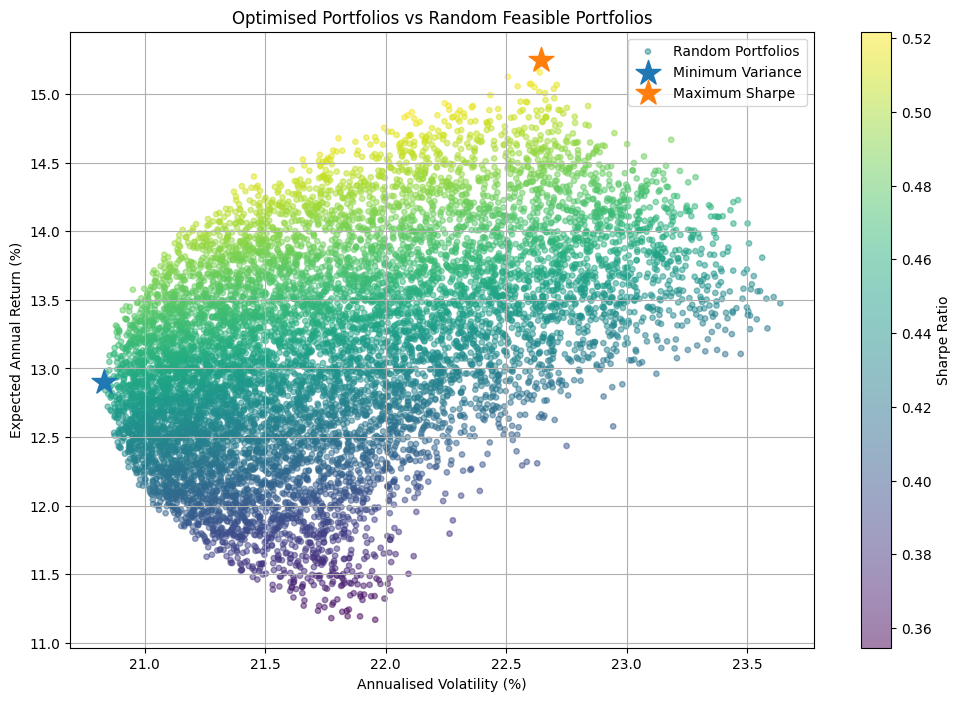

In [158]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    random_volatilities * 100,
    random_returns * 100,
    c=random_sharpes,
    cmap="viridis",
    alpha=0.5,
    s=15,
    label="Random Portfolios"
)


plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.scatter(
    min_var_vol_check * 100,
    min_var_return_check * 100,
    marker="*",
    s=350,
    label="Minimum Variance"
)

plt.scatter(
    max_sharpe_vol_check * 100,
    max_sharpe_return_check * 100,
    marker="*",
    s=350,
    label="Maximum Sharpe"
)
plt.xlabel(
    "Annualised Volatility (%)"
)
plt.ylabel(
    "Expected Annual Return (%)"
)

plt.title(
    "Optimised Portfolios vs Random Feasible Portfolios"
)
plt.legend()
plt.grid(True)
# new code from here
plt.savefig(
    "../figures/optimised_vs_random_portfolios.png",
    dpi=300
)

plt.show()

In [159]:
final_validation_summary = pd.DataFrame(
    {

        "Validation_Test": [
            "Minimum Variance Weight Sum",
            "Minimum Variance Constraints",
            "Maximum Sharpe Weight Sum",
            "Maximum Sharpe Constraints",
            "Minimum Variance Optimisation Success",
            "Maximum Sharpe Optimisation Success",
            "Maximum Sharpe Independent Calculation",
            "Maximum Sharpe Multi-Start Test",
            "Optimised Sharpe vs Best Random",
            "Optimised Volatility vs Lowest Random"

        ],
        "Result": [
            np.isclose(
                min_var_weights.sum(),
                1
            ),
            (
                np.all(min_var_weights >= 0)
                and
                np.all(min_var_weights <= 0.40)
            ),
            np.isclose(
                max_sharpe_weights.sum(),
                1
            ),
            (
                np.all(max_sharpe_weights >= 0)
                and
                np.all(max_sharpe_weights <= 0.40)
            ),
            min_var_result.success,
            max_sharpe_result.success,
            np.isclose(
                max_sharpe_result.fun,
                -max_sharpe_sharpe_check,
                atol=1e-6
            ),

            "Consistent across starting portfolios",
            max_sharpe_sharpe_check
            >
            best_random_sharpe,
            min_var_vol_check
            <
            best_random_min_vol
        ]
    }
)

print(
    final_validation_summary
)

                          Validation_Test  \
0             Minimum Variance Weight Sum   
1            Minimum Variance Constraints   
2               Maximum Sharpe Weight Sum   
3              Maximum Sharpe Constraints   
4   Minimum Variance Optimisation Success   
5     Maximum Sharpe Optimisation Success   
6  Maximum Sharpe Independent Calculation   
7         Maximum Sharpe Multi-Start Test   
8         Optimised Sharpe vs Best Random   
9   Optimised Volatility vs Lowest Random   

                                  Result  
0                                   True  
1                                   True  
2                                   True  
3                                   True  
4                                   True  
5                                   True  
6                                   True  
7  Consistent across starting portfolios  
8                                   True  
9                                   True  


In [160]:
validation_comparison.to_csv(
    "../data/processed/portfolio_validation_results.csv",
    index=False
)

final_validation_summary.to_csv(
    "../data/processed/portfolio_validation_summary.csv",
    index=False
)
print(
    "Validation results successfully saved."
)

Validation results successfully saved.


In [161]:
train_returns = returns.loc[
    "2001-07-31":"2020-12-31"
].copy()

test_returns = returns.loc[
    "2021-01-01":"2026-07-28"
].copy()

print("Training period:")
print(train_returns.index.min(), "to", train_returns.index.max())

print("\nTraining observations:")
print(len(train_returns))

print("\nTesting period:")
print(test_returns.index.min(), "to", test_returns.index.max())

print("\nTesting observations:")
print(len(test_returns))

Training period:
2001-07-31 00:00:00 to 2020-12-31 00:00:00

Training observations:
4940

Testing period:
2021-01-04 00:00:00 to 2026-07-28 00:00:00

Testing observations:
1408


In [162]:
training_annual_returns = train_returns.mean() * 252
training_annual_covariance = train_returns.cov() * 252

print("Training Annual Returns:")
print(training_annual_returns)

print("\nTraining Annual Covariance Matrix:")
print(training_annual_covariance)

Training Annual Returns:
CBA    0.130887
NAB    0.073927
WBC    0.100438
ANZ    0.106566
MQG    0.176424
dtype: float64

Training Annual Covariance Matrix:
          CBA       NAB       WBC       ANZ       MQG
CBA  0.050038  0.041954  0.042321  0.042596  0.041787
NAB  0.041954  0.062921  0.045943  0.049536  0.051993
WBC  0.042321  0.045943  0.059124  0.049899  0.045372
ANZ  0.042596  0.049536  0.049899  0.065912  0.050383
MQG  0.041787  0.051993  0.045372  0.050383  0.120016


In [163]:
training_daily_rf = daily_rf_return.loc[
    train_returns.index
]

training_annual_risk_free_rate = (
    training_daily_rf.mean() * 252
)

print("Training Annual Risk-Free Rate:")
print(
    format(training_annual_risk_free_rate, ".6%")
)

Training Annual Risk-Free Rate:
3.382114%


In [164]:
def training_portfolio_variance(weights):
    return np.dot(
        weights,
        np.dot(
            training_annual_covariance,
            weights
        )
    )


training_min_var_result = minimize(
    training_portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

training_min_var_weights = (
    training_min_var_result.x
)

print("Minimum Variance optimisation successful:")
print(training_min_var_result.success)

print("\nTraining Minimum Variance Weights:")

for bank, weight in zip(
    banks,
    training_min_var_weights
):
    print(
        bank + ": " + format(weight, ".6%")
    )

Minimum Variance optimisation successful:
True

Training Minimum Variance Weights:
CBA: 40.000000%
NAB: 20.726500%
WBC: 26.710696%
ANZ: 8.841787%
MQG: 3.721017%


In [165]:
def training_negative_sharpe(weights):
    portfolio_return = np.dot(
        weights,
        training_annual_returns
    )

    portfolio_volatility = np.sqrt(
        np.dot(
            weights,
            np.dot(
                training_annual_covariance,
                weights
            )
        )
    )

    sharpe = (
        portfolio_return
        - training_annual_risk_free_rate
    ) / portfolio_volatility

    return -sharpe


training_max_sharpe_result = minimize(
    training_negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

training_max_sharpe_weights = (
    training_max_sharpe_result.x
)

print("Maximum Sharpe optimisation successful:")
print(training_max_sharpe_result.success)

print("\nTraining Maximum Sharpe Weights:")

for bank, weight in zip(
    banks,
    training_max_sharpe_weights
):
    print(
        bank + ": " + format(weight, ".6%")
    )

Maximum Sharpe optimisation successful:
True

Training Maximum Sharpe Weights:
CBA: 40.000000%
NAB: 0.000000%
WBC: 8.392472%
ANZ: 11.607528%
MQG: 40.000000%


In [166]:
equal_weights = np.ones(len(banks)) / len(banks)
print("Equal Weight Portfolio:")

for bank, weight in zip(
    banks,
    equal_weights
):
    print(
        bank + ": " + format(weight, ".2%")
    )

Equal Weight Portfolio:
CBA: 20.00%
NAB: 20.00%
WBC: 20.00%
ANZ: 20.00%
MQG: 20.00%


In [167]:
test_min_var = test_returns.dot(
    training_min_var_weights
)
test_max_sharpe = test_returns.dot(
    training_max_sharpe_weights
)
test_equal_weight = test_returns.dot(
    equal_weights
)

print("Test portfolio returns calculated successfully.")
print("\nObservations:")
print("Minimum Variance:", len(test_min_var))
print("Maximum Sharpe:", len(test_max_sharpe))
print("Equal Weight:", len(test_equal_weight))

Test portfolio returns calculated successfully.

Observations:
Minimum Variance: 1408
Maximum Sharpe: 1408
Equal Weight: 1408


In [168]:
def calculate_oos_metrics(
    portfolio_returns,
    risk_free_rate
):

    annual_return = (
        portfolio_returns.mean() * 252
    )
    annual_volatility = (
        portfolio_returns.std() * np.sqrt(252)
    )
    sharpe_ratio = (
        annual_return - risk_free_rate
    ) / annual_volatility
    total_return = (
        (1 + portfolio_returns).prod() - 1
    )
    return (
        annual_return,
        annual_volatility,
        sharpe_ratio,
        total_return
    )

min_var_oos = calculate_oos_metrics(
    test_min_var,
    training_annual_risk_free_rate
)

max_sharpe_oos = calculate_oos_metrics(
    test_max_sharpe,
    training_annual_risk_free_rate
)

equal_weight_oos = calculate_oos_metrics(
    test_equal_weight,
    training_annual_risk_free_rate
)

In [169]:
oos_results = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ],

    "Annual Return": [
        equal_weight_oos[0],
        min_var_oos[0],
        max_sharpe_oos[0]
    ],

    "Annual Volatility": [
        equal_weight_oos[1],
        min_var_oos[1],
        max_sharpe_oos[1]
    ],

    "Sharpe Ratio": [
        equal_weight_oos[2],
        min_var_oos[2],
        max_sharpe_oos[2]
    ],

    "Total Return": [
        equal_weight_oos[3],
        min_var_oos[3],
        max_sharpe_oos[3]
    ]
})

print(
    oos_results.round(6)
)

          Portfolio  Annual Return  Annual Volatility  Sharpe Ratio  \
0      Equal Weight       0.179388           0.167359      0.869788   
1  Minimum Variance       0.186476           0.174491      0.874858   
2    Maximum Sharpe       0.182373           0.175230      0.847750   

   Total Return  
0      1.518434  
1      1.602070  
2      1.541465  


In [170]:
cumulative_oos = pd.DataFrame({
    "Equal Weight":
        (1 + test_equal_weight).cumprod(),
    "Minimum Variance":
        (1 + test_min_var).cumprod(),
    "Maximum Sharpe":
        (1 + test_max_sharpe).cumprod()
})

cumulative_oos.head()

,Equal Weight,Minimum Variance,Maximum Sharpe
Date,,,
2021-01-04,1.014790,1.016334,1.015245
2021-01-05,1.008362,1.009570,1.009306
2021-01-06,0.997086,1.001688,0.996538
2021-01-07,1.024506,1.028274,1.019378
2021-01-08,1.038213,1.041692,1.034045


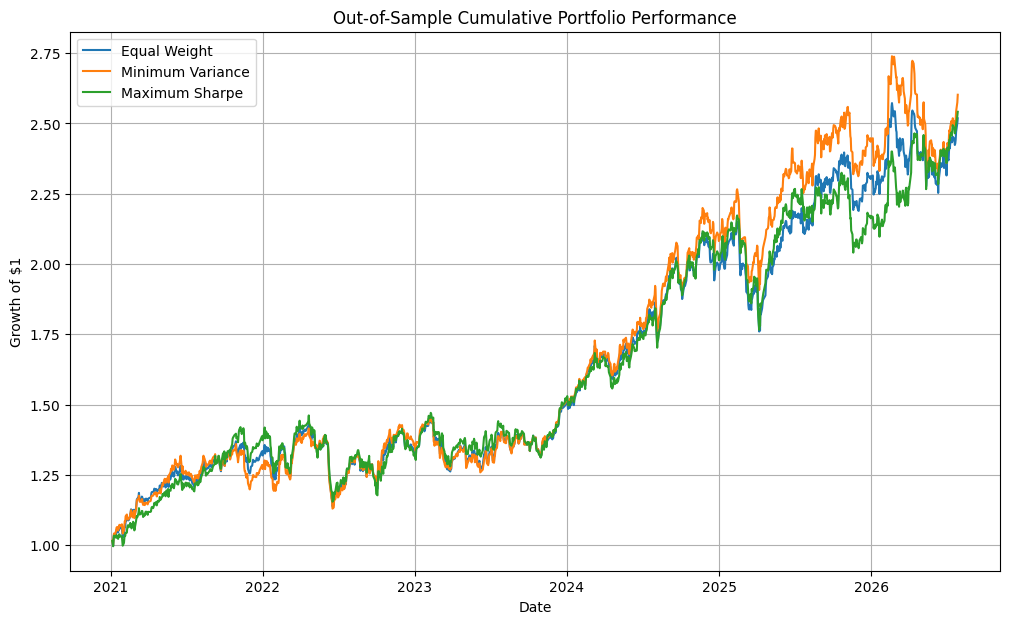

In [171]:
plt.figure(figsize=(12, 7))
plt.plot(
    cumulative_oos.index,
    cumulative_oos["Equal Weight"],
    label="Equal Weight"
)

plt.plot(
    cumulative_oos.index,
    cumulative_oos["Minimum Variance"],
    label="Minimum Variance"
)

plt.plot(
    cumulative_oos.index,
    cumulative_oos["Maximum Sharpe"],
    label="Maximum Sharpe"
)

plt.title(
    "Out-of-Sample Cumulative Portfolio Performance"
)
plt.xlabel("Date")

plt.ylabel(
    "Growth of $1"
)
plt.legend()
plt.grid(True)
plt.savefig(
    "../figures/oos_cumulative_portfolio_performance.png",
    dpi=300
)
plt.show()

In [172]:
oos_drawdowns = (
    cumulative_oos
    / cumulative_oos.cummax()
    - 1
)

print("Maximum Drawdowns:")
print(
    oos_drawdowns.min()
)

Maximum Drawdowns:
Equal Weight       -0.209342
Minimum Variance   -0.201635
Maximum Sharpe     -0.209883
dtype: float64


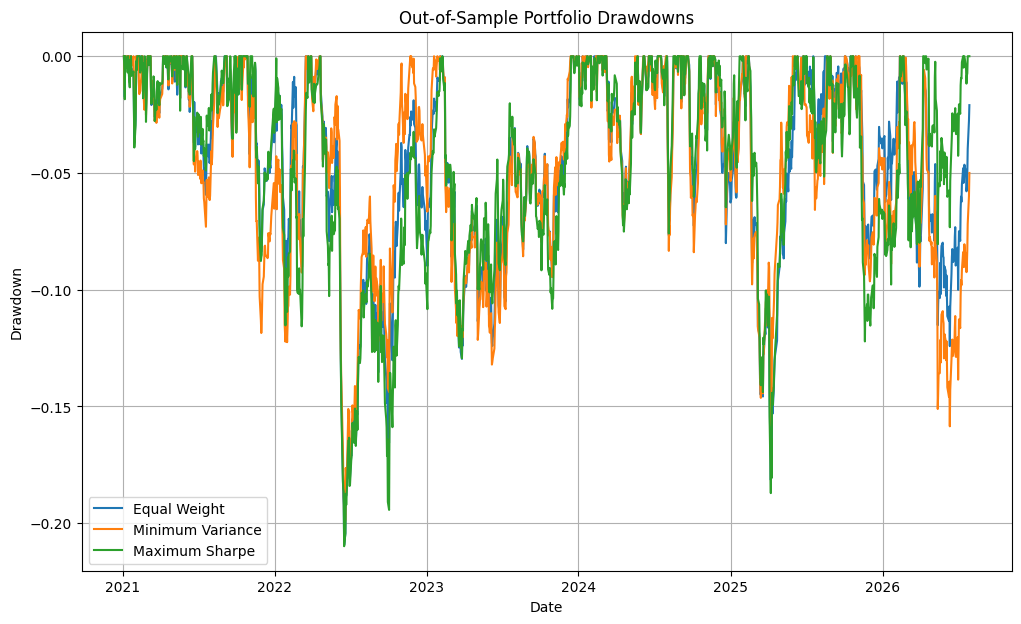

In [173]:
plt.figure(figsize=(12, 7))
plt.plot(
    oos_drawdowns.index,
    oos_drawdowns["Equal Weight"],
    label="Equal Weight"
)

plt.plot(
    oos_drawdowns.index,
    oos_drawdowns["Minimum Variance"],
    label="Minimum Variance"
)

plt.plot(
    oos_drawdowns.index,
    oos_drawdowns["Maximum Sharpe"],
    label="Maximum Sharpe"
)

plt.title(
    "Out-of-Sample Portfolio Drawdowns"
)

plt.xlabel("Date")

plt.ylabel(
    "Drawdown"
)

plt.legend()
plt.grid(True)
plt.savefig(
    "../figures/oos_portfolio_drawdowns.png",
    dpi=300
)
plt.show()

In [174]:
oos_summary = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ],
    "Return": [
        equal_weight_oos[0],
        min_var_oos[0],
        max_sharpe_oos[0]
    ],

    "Volatility": [
        equal_weight_oos[1],
        min_var_oos[1],
        max_sharpe_oos[1]
    ],

    "Sharpe": [
        equal_weight_oos[2],
        min_var_oos[2],
        max_sharpe_oos[2]
    ],

    "Total Return": [
        equal_weight_oos[3],
        min_var_oos[3],
        max_sharpe_oos[3]
    ],

    "Maximum Drawdown": [
        oos_drawdowns["Equal Weight"].min(),
        oos_drawdowns["Minimum Variance"].min(),
        oos_drawdowns["Maximum Sharpe"].min()
    ]

})

print(
    oos_summary.round(6)
)

          Portfolio    Return  Volatility    Sharpe  Total Return  \
0      Equal Weight  0.179388    0.167359  0.869788      1.518434   
1  Minimum Variance  0.186476    0.174491  0.874858      1.602070   
2    Maximum Sharpe  0.182373    0.175230  0.847750      1.541465   

   Maximum Drawdown  
0         -0.209342  
1         -0.201635  
2         -0.209883  


In [175]:
in_sample_results = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ],
    "Return": [
        0.1313,
        min_var_return_check,
        max_sharpe_return_check
    ],
    "Volatility": [
        0.2147,
        min_var_vol_check,
        max_sharpe_vol_check
    ],
    "Sharpe": [
        0.4542,
        min_var_sharpe_check,
        max_sharpe_sharpe_check
    ]
})

in_sample_results["Period"] = "In-Sample"
oos_comparison = oos_summary[
    ["Portfolio", "Return", "Volatility", "Sharpe"]
].copy()
oos_comparison["Period"] = "Out-of-Sample"
in_sample_results = in_sample_results[
    ["Period", "Portfolio", "Return", "Volatility", "Sharpe"]
]
oos_comparison = oos_comparison[
    ["Period", "Portfolio", "Return", "Volatility", "Sharpe"]
]
in_vs_oos = pd.concat(
    [in_sample_results, oos_comparison],
    ignore_index=True
)
print(
    in_vs_oos.round(6)
)

          Period         Portfolio    Return  Volatility    Sharpe
0      In-Sample      Equal Weight  0.131300    0.214700  0.454200
1      In-Sample  Minimum Variance  0.128977    0.208302  0.456816
2      In-Sample    Maximum Sharpe  0.152488    0.226427  0.524084
3  Out-of-Sample      Equal Weight  0.179388    0.167359  0.869788
4  Out-of-Sample  Minimum Variance  0.186476    0.174491  0.874858
5  Out-of-Sample    Maximum Sharpe  0.182373    0.175230  0.847750


In [176]:
oos_summary.to_csv(
    "../data/processed/out_of_sample_results.csv",
    index=False
)

cumulative_oos.to_csv(
    "../data/processed/out_of_sample_cumulative_returns.csv"
)
oos_drawdowns.to_csv(
    "../data/processed/out_of_sample_drawdowns.csv"
)
print("Out-of-sample results saved successfully.")

Out-of-sample results saved successfully.


In [177]:
in_sample_results = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ],
    "Return": [
        0.1313,
        min_var_return_check,
        max_sharpe_return_check
    ],
    "Volatility": [
        0.2147,
        min_var_vol_check,
        max_sharpe_vol_check
    ],
    "Sharpe": [
        0.4542,
        min_var_sharpe_check,
        max_sharpe_sharpe_check
    ]
})

in_sample_results["Period"] = "In-Sample"
oos_comparison = oos_summary[
    ["Portfolio", "Return", "Volatility", "Sharpe"]
].copy()

oos_comparison["Period"] = "Out-of-Sample"
in_sample_results = in_sample_results[
    ["Period", "Portfolio", "Return", "Volatility", "Sharpe"]
]

oos_comparison = oos_comparison[
    ["Period", "Portfolio", "Return", "Volatility", "Sharpe"]
]

in_vs_oos = pd.concat(
    [in_sample_results, oos_comparison],
    ignore_index=True
)

print(
    in_vs_oos.round(6)
)

          Period         Portfolio    Return  Volatility    Sharpe
0      In-Sample      Equal Weight  0.131300    0.214700  0.454200
1      In-Sample  Minimum Variance  0.128977    0.208302  0.456816
2      In-Sample    Maximum Sharpe  0.152488    0.226427  0.524084
3  Out-of-Sample      Equal Weight  0.179388    0.167359  0.869788
4  Out-of-Sample  Minimum Variance  0.186476    0.174491  0.874858
5  Out-of-Sample    Maximum Sharpe  0.182373    0.175230  0.847750


In [178]:
returns = returns.sort_index()
rolling_volatility = returns.rolling(window=252).std() * np.sqrt(252)

print("Rolling volatility shape:", rolling_volatility.shape)

print("\nMissing values:")
print(rolling_volatility.isna().sum())

print("\nFirst valid observation:")
print(rolling_volatility.dropna().head())

print("\nLatest rolling volatility:")
print(rolling_volatility.dropna().tail(1))

Rolling volatility shape: (6348, 5)

Missing values:
CBA    251
NAB    251
WBC    251
ANZ    251
MQG    251
dtype: int64

First valid observation:
                 CBA       NAB       WBC       ANZ       MQG
Date                                                        
2002-07-17  0.198828  0.259305  0.184757  0.249789  0.281397
2002-07-18  0.198489  0.259229  0.184347  0.249062  0.281119
2002-07-19  0.198187  0.259118  0.184037  0.247919  0.283106
2002-07-22  0.198431  0.259600  0.183738  0.247893  0.281699
2002-07-23  0.197611  0.259590  0.183739  0.246873  0.281699

Latest rolling volatility:
                 CBA       NAB       WBC       ANZ       MQG
Date                                                        
2026-07-28  0.246917  0.220587  0.213931  0.210839  0.234621


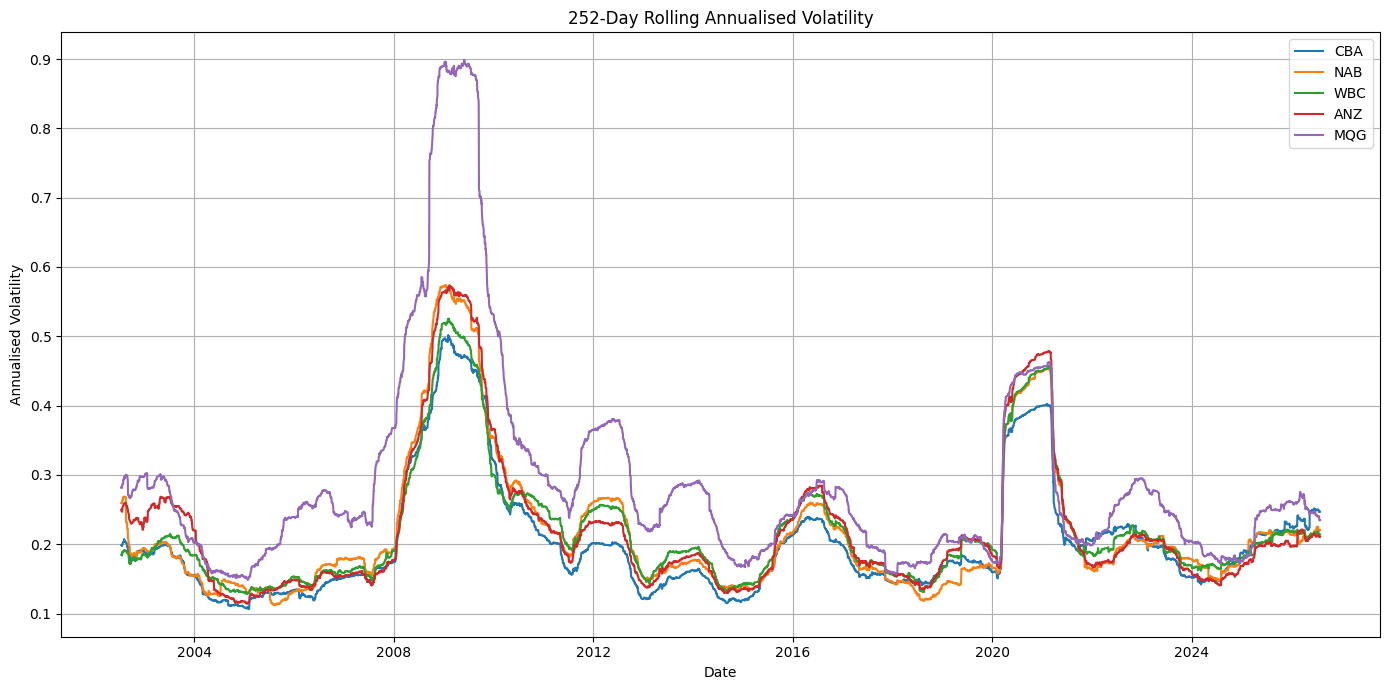

In [179]:
plt.figure(figsize=(14, 7))
for bank in banks:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[bank],
        label=bank
    )

plt.title("252-Day Rolling Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/rolling_volatility_252d.png", dpi=300)
plt.show()

In [180]:
rolling_volatility_max = pd.DataFrame({
    "Maximum Rolling Volatility": rolling_volatility.max(),
    "Date of Maximum": rolling_volatility.idxmax()
})

print(rolling_volatility_max.sort_values(
    "Maximum Rolling Volatility",
    ascending=False
))

     Maximum Rolling Volatility Date of Maximum
MQG                    0.898862      2009-06-01
NAB                    0.574073      2009-01-15
ANZ                    0.573660      2009-02-13
WBC                    0.525410      2009-02-06
CBA                    0.501728      2009-02-03


In [181]:
average_rolling_volatility = rolling_volatility.mean()
print("Average 252-day rolling annualised volatility:")
print(
    average_rolling_volatility.sort_values(
        ascending=False
    ).round(4)
)

Average 252-day rolling annualised volatility:
MQG    0.2900
ANZ    0.2217
WBC    0.2185
NAB    0.2168
CBA    0.2022
dtype: float64


In [182]:
market_path = "../data/processed/XJT_market_data.csv"
if not os.path.exists(market_path):
    raise FileNotFoundError(
        "XJT_market_data.csv was not found. Run the corrected "
        "06_capm_regression_XJT_FIXED_FINAL.ipynb first."
    )

market = pd.read_csv(
    market_path,
    index_col="Date",
    parse_dates=True
)

if "Market_Level" not in market.columns:
    raise ValueError(
        "XJT_market_data.csv must contain the Market_Level column."
    )

market = market[["Market_Level"]].apply(pd.to_numeric, errors="coerce").dropna()
market = market[~market.index.duplicated(keep="last")].sort_index()

print("XJT benchmark data shape:", market.shape)
print("Start date:", market.index.min().date())
print("End date:", market.index.max().date())
print("Missing values:", market.isna().sum().sum())
print("Duplicate dates:", market.index.duplicated().sum())
print("Dates sorted correctly:", market.index.is_monotonic_increasing)

print("\nFirst 5 observations:")
print(market.head())

print("\nLast 5 observations:")
print(market.tail())


NameError: name 'os' is not defined

In [ ]:
market_returns = market["Market_Level"].pct_change()
market_returns.name = "XJT_Gross_Total_Return"

rolling_beta_data = pd.concat(
    [returns, market_returns],
    axis=1,
    join="inner"
).dropna()

print("Rolling beta dataset shape:")
print(rolling_beta_data.shape)

print("\nDate range:")
print("Start:", rolling_beta_data.index.min().date())
print("End:", rolling_beta_data.index.max().date())

print("\nMissing values:")
print(rolling_beta_data.isna().sum())

print("\nFirst 5 observations:")
print(rolling_beta_data.head())


In [ ]:
rolling_beta = pd.DataFrame(index=rolling_beta_data.index)
market_column = "XJT_Gross_Total_Return"

for bank in ["CBA", "NAB", "WBC", "ANZ", "MQG"]:
    rolling_covariance = (
        rolling_beta_data[bank]
        .rolling(window=252)
        .cov(rolling_beta_data[market_column])
    )

    rolling_market_variance = (
        rolling_beta_data[market_column]
        .rolling(window=252)
        .var()
    )

    rolling_beta[bank] = rolling_covariance / rolling_market_variance

print("Rolling beta shape:")
print(rolling_beta.shape)

print("\nMissing values:")
print(rolling_beta.isna().sum())

print("\nFirst valid rolling beta:")
print(rolling_beta.dropna().head(1))

print("\nAverage rolling beta:")
print(rolling_beta.mean().sort_values(ascending=False).round(4))

print("\nMinimum rolling beta:")
print(rolling_beta.min().sort_values().round(4))

print("\nMaximum rolling beta:")
print(rolling_beta.max().sort_values(ascending=False).round(4))

rolling_beta.to_csv(
    "../data/processed/rolling_beta_XJT.csv"
)

print("\nSaved: ../data/processed/rolling_beta_XJT.csv")


In [ ]:
import os
import statsmodels.api as sm

crisis_periods = {
    "GFC": ("2007-10-01", "2009-03-31"),
    "COVID": ("2020-02-19", "2021-06-30"),
    "Rate Hikes": ("2022-05-03", "2023-11-07")
}
risk_free_path = "../data/processed/daily_risk_free_rate.csv"

if os.path.exists(risk_free_path):
    crisis_rf = pd.read_csv(
        risk_free_path,
        index_col="Date",
        parse_dates=True
    )
    if "Risk_Free_Return" not in crisis_rf.columns:
        if len(crisis_rf.columns) == 1:
            crisis_rf.columns = ["Risk_Free_Return"]
        else:
            raise ValueError("daily_risk_free_rate.csv has an unexpected structure.")
else:
    annual_rf_for_crisis = 0.033821
    daily_rf_for_crisis = (
        (1 + annual_rf_for_crisis) ** (1 / 252) - 1
    )
    crisis_rf = pd.DataFrame(
        {"Risk_Free_Return": daily_rf_for_crisis},
        index=returns.index
    )

crisis_rf = crisis_rf.sort_index()
crisis_capm_data = pd.concat(
    [
        returns,
        market_returns,
        crisis_rf["Risk_Free_Return"]
    ],
    axis=1,
    join="inner"
).dropna()

crisis_capm_data["Market_Excess_Return"] = (
    crisis_capm_data["XJT_Gross_Total_Return"]
    - crisis_capm_data["Risk_Free_Return"]
)

for bank in ["CBA", "NAB", "WBC", "ANZ", "MQG"]:
    crisis_capm_data[f"{bank}_Excess_Return"] = (
        crisis_capm_data[bank]
        - crisis_capm_data["Risk_Free_Return"]
    )

crisis_rows = []

for period, (start_date, end_date) in crisis_periods.items():
    period_data = crisis_capm_data.loc[start_date:end_date]

    for bank in ["CBA", "NAB", "WBC", "ANZ", "MQG"]:
        pair = period_data[
            [f"{bank}_Excess_Return", "Market_Excess_Return"]
        ].dropna()

        if len(pair) < 30:
            continue

        y = pair[f"{bank}_Excess_Return"]
        X = sm.add_constant(pair[["Market_Excess_Return"]])
        model = sm.OLS(y, X).fit()
        beta_ci = model.conf_int().loc["Market_Excess_Return"]

        crisis_rows.append({
            "Period": period,
            "Bank": bank,
            "Alpha": model.params["const"],
            "Alpha_t_stat": model.tvalues["const"],
            "Alpha_p_value": model.pvalues["const"],
            "Beta": model.params["Market_Excess_Return"],
            "Beta_t_stat": model.tvalues["Market_Excess_Return"],
            "Beta_p_value": model.pvalues["Market_Excess_Return"],
            "Beta_CI_95_Lower": beta_ci.iloc[0],
            "Beta_CI_95_Upper": beta_ci.iloc[1],
            "R_Squared": model.rsquared,
            "N_Observations": int(model.nobs)
        })

crisis_capm_results = pd.DataFrame(crisis_rows)

crisis_beta_table = crisis_capm_results.pivot(
    index="Bank", columns="Period", values="Beta"
)
capm_summary_path = "../data/processed/capm_summary.csv"
if os.path.exists(capm_summary_path):
    corrected_capm_summary = pd.read_csv(capm_summary_path, index_col=0)
    if "Beta" in corrected_capm_summary.columns:
        crisis_beta_comparison = crisis_beta_table.copy()
        crisis_beta_comparison["Full_Sample_Beta"] = corrected_capm_summary["Beta"].reindex(
            crisis_beta_comparison.index
        )
        for period in crisis_periods:
            crisis_beta_comparison[f"{period}_Minus_Full"] = (
                crisis_beta_comparison[period]
                - crisis_beta_comparison["Full_Sample_Beta"]
            )
    else:
        crisis_beta_comparison = crisis_beta_table.copy()
else:
    crisis_beta_comparison = crisis_beta_table.copy()

crisis_capm_results.to_csv(
    "../data/processed/crisis_capm_results.csv",
    index=False
)
crisis_beta_table.to_csv(
    "../data/processed/crisis_beta_table.csv"
)
crisis_beta_comparison.to_csv(
    "../data/processed/crisis_beta_comparison.csv"
)

print("Corrected crisis CAPM files saved.")
print("\nCrisis beta table:")
print(crisis_beta_table.round(4))


In [ ]:
annual_risk_free = 0.033821
daily_risk_free = (1 + annual_risk_free) ** (1 / 252) - 1

rolling_sharpe = pd.DataFrame(index=returns.index)

for bank in ["CBA", "NAB", "WBC", "ANZ", "MQG"]:
    
    rolling_mean = returns[bank].rolling(window=252).mean()
    rolling_std = returns[bank].rolling(window=252).std()
    
    rolling_sharpe[bank] = (
        (rolling_mean - daily_risk_free)
        / rolling_std
    ) * np.sqrt(252)

print("Rolling Sharpe shape:")
print(rolling_sharpe.shape)

print("\nMissing values:")
print(rolling_sharpe.isna().sum())

print("\nFirst valid rolling Sharpe:")
print(rolling_sharpe.dropna().head(1))

In [ ]:
plt.figure(figsize=(14, 7))
for bank in ["CBA", "NAB", "WBC", "ANZ", "MQG"]:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[bank],
        label=bank
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("252-Day Rolling Sharpe Ratio of Australian Banks")
plt.xlabel("Date")
plt.ylabel("Annualised Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../figures/rolling_sharpe_252d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
rolling_sharpe_summary = pd.DataFrame({
    "Average Rolling Sharpe": rolling_sharpe.mean(),
    "Minimum Rolling Sharpe": rolling_sharpe.min(),
    "Maximum Rolling Sharpe": rolling_sharpe.max()
})

print("Rolling Sharpe Ratio Summary:")
print(
    rolling_sharpe_summary
    .sort_values("Average Rolling Sharpe", ascending=False)
    .round(4)
)

In [ ]:
worst_rolling_sharpe = pd.DataFrame({
    "Minimum Rolling Sharpe": rolling_sharpe.min(),
    "Worst Period": [
        rolling_sharpe[bank].idxmin().date()
        for bank in rolling_sharpe.columns
    ]
})

print("Worst 252-day rolling Sharpe period:")
print(
    worst_rolling_sharpe
    .sort_values("Minimum Rolling Sharpe")
    .round(4)
)

In [ ]:
print("Type:")
print(type(optimized_portfolio_results))

print("\nShape:")
print(optimized_portfolio_results.shape)

print("\nColumns:")
print(optimized_portfolio_results.columns.tolist())

print("\nIndex:")
print(optimized_portfolio_results.index.tolist())

print("\nExisting results:")
print(optimized_portfolio_results)

print("Existing portfolio weights:")
print(portfolio_weights_table)

In [ ]:
stress_scenarios = {
    "Moderate Stress (-10%)": -0.10,
    "Severe Stress (-20%)": -0.20,
    "Extreme Stress (-30%)": -0.30
}

print("Stress scenarios:")
for scenario, shock in stress_scenarios.items():
    print(scenario + ": " + format(shock, ".0%"))

In [ ]:
stress_results = []
for scenario, shock in stress_scenarios.items():

    for portfolio in portfolio_weights_table.columns:

        weights = portfolio_weights_table[portfolio]

        portfolio_stress_return = (
            weights * shock
        ).sum()

        stress_results.append({
            "Scenario": scenario,
            "Portfolio": portfolio,
            "Stress Return": portfolio_stress_return
        })

stress_results = pd.DataFrame(stress_results)
print("Equal shock stress-test results:")
print(stress_results.round(4))

In [ ]:
bank_stress = pd.Series({
    "CBA": -0.10,
    "NAB": -0.10,
    "WBC": -0.10,
    "ANZ": -0.10,
    "MQG": -0.25
})

print("Differentiated bank stress:")
print(bank_stress)

In [ ]:
differentiated_stress_results = []
for portfolio in portfolio_weights_table.columns:
    weights = portfolio_weights_table[portfolio]
    portfolio_stress_return = (
        weights * bank_stress
    ).sum()

    differentiated_stress_results.append({
        "Portfolio": portfolio,
        "Stress Return": portfolio_stress_return
    })

differentiated_stress_results = pd.DataFrame(
    differentiated_stress_results
)

print("Differentiated stress-test results:")
print(
    differentiated_stress_results
    .sort_values("Stress Return", ascending=False)
    .round(4)
)

In [ ]:
mqg_exposure = portfolio_weights_table.loc["MQG"]
print("MQG exposure across portfolios:")
print(mqg_exposure.round(4))

In [ ]:
stress_results.to_csv(
    "../data/processed/stress_test_results.csv",
    index=False
)

differentiated_stress_results.to_csv(
    "../data/processed/differentiated_stress_results.csv",
    index=False
)
print("Stress-test results saved successfully.")

In [ ]:
%whos

In [ ]:
returns_2001_2015 = returns.loc["2001-07-31":"2015-12-31"].copy()
returns_10y = returns.loc["2016-01-01":"2026-07-28"].copy()
returns_5y = returns.loc["2021-01-01":"2026-07-28"].copy()

print("Full sample:")
print(returns.index.min().date(), "to", returns.index.max().date())
print("Observations:", len(returns))

print("\n2001–2015 sample:")
print(
    returns_2001_2015.index.min().date(),
    "to",
    returns_2001_2015.index.max().date()
)
print("Observations:", len(returns_2001_2015))

print("\n2016–2026 sample:")
print(
    returns_10y.index.min().date(),
    "to",
    returns_10y.index.max().date()
)
print("Observations:", len(returns_10y))

print("\n2021–2026 sample:")
print(
    returns_5y.index.min().date(),
    "to",
    returns_5y.index.max().date()
)
print("Observations:", len(returns_5y))

In [ ]:
robustness_covariances = {
    "2001-2015": returns_2001_2015.cov() * 252,
    "2016-2026": returns_10y.cov() * 252,
    "2021-2026": returns_5y.cov() * 252
}

robustness_means = {
    "2001-2015": returns_2001_2015.mean() * 252,
    "2016-2026": returns_10y.mean() * 252,
    "2021-2026": returns_5y.mean() * 252
}

for period in robustness_means:
    print("\n" + period + " annualised expected returns:")
    print(robustness_means[period].round(4))

In [ ]:
bank_names = ["CBA", "NAB", "WBC", "ANZ", "MQG"]
def optimise_robustness(mean_returns, covariance_matrix, risk_free_rate):

    n = len(bank_names)

    def portfolio_variance(weights):
        return weights @ covariance_matrix.values @ weights

    def negative_sharpe(weights):
        portfolio_return = weights @ mean_returns.values
        portfolio_volatility = np.sqrt(portfolio_variance(weights))

        return -(
            (portfolio_return - risk_free_rate)
            / portfolio_volatility
        )

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    bounds = [(0, 0.40)] * n
    initial_weights = np.array([0.20] * n)

    min_variance = minimize(
        portfolio_variance,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    max_sharpe = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return {
        "Minimum Variance": min_variance.x,
        "Maximum Sharpe": max_sharpe.x
    }

In [ ]:
risk_free_rate = 0.033821
robustness_weights = {}

for period in ["2001-2015", "2016-2026", "2021-2026"]:

    robustness_weights[period] = optimise_robustness(
        robustness_means[period],
        robustness_covariances[period],
        risk_free_rate
    )

print("Robustness optimisation completed.")

In [ ]:
robustness_weight_table = pd.DataFrame(
    index=bank_names
)

for period in ["2001-2015", "2016-2026", "2021-2026"]:
    robustness_weight_table[
        f"{period} Min Variance"
    ] = robustness_weights[period]["Minimum Variance"]

    robustness_weight_table[
        f"{period} Max Sharpe"
    ] = robustness_weights[period]["Maximum Sharpe"]

print(
    robustness_weight_table
    .mul(100)
    .round(2)
)

In [ ]:
full_sample_weights = portfolio_weights_table[
    ["Minimum Variance", "Maximum Sharpe"]
].copy()

full_sample_weights.columns = [
    "Full Sample Min Variance",
    "Full Sample Max Sharpe"
]
robustness_comparison = pd.concat(
    [
        full_sample_weights,
        robustness_weight_table
    ],
    axis=1
)
print(
    robustness_comparison
    .mul(100)
    .round(2)
)

In [ ]:
stability_results = []
for portfolio in ["Minimum Variance", "Maximum Sharpe"]:
    full_weights = portfolio_weights_table[portfolio]

    for period in ["2001-2015", "2016-2026", "2021-2026"]:

        alternative_weights = robustness_weights[period][portfolio]

        absolute_change = np.abs(
            full_weights.values - alternative_weights
        )

        total_weight_change = absolute_change.sum()
        maximum_bank_change = absolute_change.max()

        stability_results.append({
            "Portfolio": portfolio,
            "Comparison": f"Full Sample vs {period}",
            "Total Absolute Weight Change": total_weight_change,
            "Largest Individual Weight Change": maximum_bank_change
        })

stability_results = pd.DataFrame(stability_results)
print(
    stability_results
    .round(4)
)

In [ ]:
robustness_weight_table.to_csv(
    "../data/processed/robustness_weights.csv"
)
robustness_comparison.to_csv(
    "../data/processed/robustness_comparison.csv"
)
stability_results.to_csv(
    "../data/processed/robustness_stability.csv",
    index=False
)

print("Robustness results saved successfully.")

In [ ]:
print("oos_results columns:")
print(oos_results.columns.tolist())

print("\noos_results:")
print(oos_results)

In [ ]:
risk_model_comparison = pd.DataFrame({
    "Portfolio": [
        "Equal Weight",
        "Minimum Variance",
        "Maximum Sharpe"
    ],
    "In_Sample_Volatility": [
        optimized_portfolio_results.loc["Equal Weight", "Annual_Volatility"],
        optimized_portfolio_results.loc["Minimum Variance", "Annual_Volatility"],
        optimized_portfolio_results.loc["Maximum Sharpe", "Annual_Volatility"]
    ],
    "In_Sample_Sharpe": [
        optimized_portfolio_results.loc["Equal Weight", "Sharpe_Ratio"],
        optimized_portfolio_results.loc["Minimum Variance", "Sharpe_Ratio"],
        optimized_portfolio_results.loc["Maximum Sharpe", "Sharpe_Ratio"]
    ],
    "OOS_Volatility": [
        oos_results.loc[
            oos_results["Portfolio"] == "Equal Weight", "Annual Volatility"
        ].iloc[0],
        oos_results.loc[
            oos_results["Portfolio"] == "Minimum Variance", "Annual Volatility"
        ].iloc[0],
        oos_results.loc[
            oos_results["Portfolio"] == "Maximum Sharpe", "Annual Volatility"
        ].iloc[0]
    ],
    "OOS_Sharpe": [
        oos_results.loc[
            oos_results["Portfolio"] == "Equal Weight", "Sharpe Ratio"
        ].iloc[0],
        oos_results.loc[
            oos_results["Portfolio"] == "Minimum Variance", "Sharpe Ratio"
        ].iloc[0],
        oos_results.loc[
            oos_results["Portfolio"] == "Maximum Sharpe", "Sharpe Ratio"
        ].iloc[0]
    ],
    "Maximum_Drawdown": [
        oos_results.loc[
            oos_results["Portfolio"] == "Equal Weight", "Maximum Drawdown"
        ].iloc[0] if "Maximum Drawdown" in oos_results.columns else -0.209342,
        oos_results.loc[
            oos_results["Portfolio"] == "Minimum Variance", "Maximum Drawdown"
        ].iloc[0] if "Maximum Drawdown" in oos_results.columns else -0.201635,
        oos_results.loc[
            oos_results["Portfolio"] == "Maximum Sharpe", "Maximum Drawdown"
        ].iloc[0] if "Maximum Drawdown" in oos_results.columns else -0.209883
    ],
    "Differentiated_Stress_Return": [
        differentiated_stress_results.loc[
            differentiated_stress_results["Portfolio"] == "Equal Weight",
            "Stress Return"
        ].iloc[0],
        differentiated_stress_results.loc[
            differentiated_stress_results["Portfolio"] == "Minimum Variance",
            "Stress Return"
        ].iloc[0],
        differentiated_stress_results.loc[
            differentiated_stress_results["Portfolio"] == "Maximum Sharpe",
            "Stress Return"
        ].iloc[0]
    ]
})

print("Risk Model Comparison:")
print(risk_model_comparison.round(4))

In [ ]:
risk_model_comparison.to_csv(
    "../data/processed/risk_model_comparison.csv",
    index=False
)
print("Risk model comparison saved successfully.")